In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# Data

In [52]:
index = [
    "qwen2.5:14b",
    "deepseek-r1:14b",
    "gemma3:27b",
    "granite-code:20b",
    "llama3.1:8b",
    "phi4:14b",
    "codestral:22b",
    "gpt-oss:20b"
]

yamllint_passed = {
    "qwen2.5:14b": [35, 51, 43, 48, 58, 46, 16, 90],
    "deepseek-r1:14b": [41, 41, 45, 56, 64, 50, 16, 96],
    "gemma3:27b": [32, 46, 47, 47, 57, 51, 14, 93],
    "granite-code:20b": [49, 55, 51, 48, 69, 69, 17, 96],
    "llama3.1:8b": [34, 47, 43, 49, 56, 38, 8, 94],
    "phi4:14b": [27, 43, 32, 47, 54, 36, 12, 86],
    "codestral:22b": [40, 41, 41, 46, 60, 40, 15, 90],
    "gpt-oss:20b": [35, 50, 42, 50, 54, 52, 16, 89]
}

ansiblelint_passed = {
    "qwen2.5:14b": [30, 37, 34, 29, 58, 41, 6, 87],
    "deepseek-r1:14b": [34, 36, 38, 33, 62, 45, 7, 93],
    "gemma3:27b": [23, 35, 35, 30, 57, 42, 6, 90],
    "granite-code:20b": [36, 41, 42, 22, 66, 62, 5, 95],
    "llama3.1:8b": [25, 33, 33, 20, 49, 19, 2, 81],
    "phi4:14b": [23, 35, 28, 28, 52, 32, 5, 85],
    "codestral:22b": [33, 34, 28, 23, 58, 33, 3, 79],
    "gpt-oss:20b": [33, 41, 34, 36, 52, 46, 10, 88]
}

molecule_passed = {
    "qwen2.5:14b": [4, 4, 8, 5, 21, 14, 5, 21],
    "deepseek-r1:14b": [8, 9, 10, 14, 27, 14, 3, 19],
    "gemma3:27b": [5, 8, 6, 5, 19, 15, 2, 24],
    "granite-code:20b": [4, 10, 11, 5, 20, 17, 2, 19],
    "llama3.1:8b": [4, 7, 5, 3, 18, 6, 0, 18],
    "phi4:14b": [4, 6, 7, 4, 13, 8, 4, 25],
    "codestral:22b": [10, 6, 11, 11, 29, 10, 1, 21],
    "gpt-oss:20b": [15, 12, 5, 6, 18, 14, 4, 32]
}

benchmark_scores = {
    "qwen2.5:14b": [0.1110, 0.1431, 0.0992, 0.1389, 0.1022, 0.0920, 0.1489, 0.1720],
    "deepseek-r1:14b": [0.1488, 0.1573, 0.1541, 0.1851, 0.1461, 0.1434, 0.1434, 0.1968],
    "gemma3:27b": [0.1492, 0.1679, 0.1488, 0.1894, 0.1389, 0.1220, 0.1496, 0.1434],
    "granite-code:20b": [0.1358, 0.1925, 0.1371, 0.1221, 0.1125, 0.1298, 0.1463, 0.1612],
    "llama3.1:8b": [0.3224, 0.3575, 0.3052, 0.3374, 0.2756, 0.2549, 0.3515, 0.2877],
    "phi4:14b": [0.1922, 0.2081, 0.2053, 0.2819, 0.1056, 0.1400, 0.1567, 0.2285],
    "codestral:22b": [0.0499, 0.0451, 0.0359, 0.0372, 0.0125, 0.0403, 0.0255, 0.0627],
    "gpt-oss:20b": [0.3736, 0.3797, 0.3955, 0.3917, 0.3463, 0.3809, 0.3553, 0.4509]
}

yamllint_scores = {
    "qwen2.5:14b": [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0009, 1.0000],
    "deepseek-r1:14b": [1.1314, 1.1127, 1.0932, 1.1284, 1.0980, 1.1041, 1.1004, 1.1128],
    "gemma3:27b": [1.1432, 1.1398, 1.1534, 1.1386, 1.1519, 1.0987, 1.1384, 1.1220],
    "granite-code:20b": [1.2037, 1.2401, 1.2077, 1.2050, 1.2302, 1.2002, 1.1860, 1.1995],
    "llama3.1:8b": [1.0609, 1.0561, 1.0702, 1.0443, 1.0628, 1.0750, 1.0593, 1.0668],
    "phi4:14b": [1.1291, 1.1449, 1.1466, 1.1908, 1.1248, 1.0851, 1.1250, 1.1478],
    "codestral:22b": [1.0077, 1.0116, 1.0038, 1.0056, 1.0116, 1.0098, 1.0105, 1.0041],
    "gpt-oss:20b": [1.2340, 1.2367, 1.2572, 1.2701, 1.1812, 1.1782, 1.2272, 1.2500]
}

ansiblelint_scores = {
    "qwen2.5:14b": [1.0000, 1.0309, 1.0256, 1.0263, 1.0449, 1.0656, 1.0435, 1.1667],
    "deepseek-r1:14b": [1.0146, 1.0510, 1.0254, 1.0122, 1.0076, 1.0278, 1.0928, 1.1359],
    "gemma3:27b": [1.0000, 1.0086, 1.0080, 1.0400, 1.0517, 1.0500, 1.0531, 1.1222],
    "granite-code:20b": [1.0000, 1.0152, 1.0063, 1.0058, 1.0053, 1.0256, 1.0370, 1.0719],
    "llama3.1:8b": [1.5250, 1.4667, 1.4756, 1.4038, 1.4706, 1.3929, 1.4824, 1.5200],
    "phi4:14b": [1.0278, 1.0536, 1.0336, 1.0621, 1.0238, 1.0769, 1.0860, 1.2258],
    "codestral:22b": [1.2353, 1.2105, 1.1579, 1.2105, 1.0909, 1.2143, 1.0588, 1.5294],
    "gpt-oss:20b": [1.0263, 1.0149, 1.0145, 1.0199, 1.0077, 1.0565, 1.0179, 1.2026]
}

def to_minutes(hm):
    h, m = hm.split(":")
    return int(h) * 60 + int(m)

duration_runs = {
    "qwen2.5:14b": [to_minutes(x) for x in ["1:42", "1:56", "1:49", "1:36", "1:45", "1:56", "2:10", "2:19"]],
    "deepseek-r1:14b": [to_minutes(x) for x in ["3:59", "4:07", "2:37", "4:06", "4:39", "4:18", "4:16", "4:11"]],
    "gemma3:27b": [to_minutes(x) for x in ["4:42", "4:02", "4:50", "4:12", "4:26", "4:54", "4:50", "5:19"]],
    "granite-code:20b": [to_minutes(x) for x in ["2:04", "2:11", "2:05", "1:30", "1:39", "2:00", "1:55", "2:04"]],
    "llama3.1:8b": [to_minutes(x) for x in ["1:43", "2:12", "2:22", "1:53", "1:59", "1:43", "2:07", "1:28"]],
    "phi4:14b": [to_minutes(x) for x in ["2:03", "1:49", "2:08", "2:11", "1:37", "1:40", "1:43", "2:11"]],
    "codestral:22b": [to_minutes(x) for x in ["1:49", "2:15", "2:00", "1:31", "1:51", "2:00", "2:00", "2:43"]],
    "gpt-oss:20b": [to_minutes(x) for x in ["4:17", "4:18", "4:37", "3:17", "6:43", "5:34", "4:47", "4:55"]]
}

df_file_information = pd.read_csv("overall_report.csv", delimiter=";")

df_molecule_passed = pd.DataFrame(molecule_passed, index=index).T
df_yamllint_passed = pd.DataFrame(yamllint_passed, index=index).T
df_ansiblelint_passed = pd.DataFrame(ansiblelint_passed, index=index).T
df_benchmark_scores = pd.DataFrame(benchmark_scores, index=index)
df_yamllint_scores = pd.DataFrame(yamllint_scores, index=index)
df_ansiblelint_scores = pd.DataFrame(ansiblelint_scores, index=index)
df_duration_runs = pd.DataFrame(duration_runs, index=index)


In [53]:
from matplotlib import cm, colors

dark_blue_cmap = colors.ListedColormap(
    cm.get_cmap("Blues")(np.linspace(0.4, 1.0, 256))
)
blue = sns.color_palette(dark_blue_cmap(np.linspace(0, 1, 10)))



/tmp/ipykernel_3773678/3357405953.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm.get_cmap("Blues")(np.linspace(0.4, 1.0, 256))


# Analysis of Benchmark-Scores

In [54]:
print(df_benchmark_scores.describe())

       qwen2.5:14b  deepseek-r1:14b  gemma3:27b  granite-code:20b  \
count     8.000000         8.000000    8.000000          8.000000   
mean      0.125912         0.159375    0.151150          0.142163   
std       0.028698         0.020329    0.020054          0.025113   
min       0.092000         0.143400    0.122000          0.112500   
25%       0.101450         0.145425    0.142275          0.127875   
50%       0.124950         0.151450    0.149000          0.136450   
75%       0.144550         0.164250    0.154175          0.150025   
max       0.172000         0.196800    0.189400          0.192500   

       llama3.1:8b  phi4:14b  codestral:22b  gpt-oss:20b  
count     8.000000  8.000000       8.000000     8.000000  
mean      0.311525  0.189787       0.038638     0.384238  
std       0.037041  0.055067       0.015193     0.031731  
min       0.254900  0.105600       0.012500     0.346300  
25%       0.284675  0.152525       0.033300     0.369025  
50%       0.313800  0.19

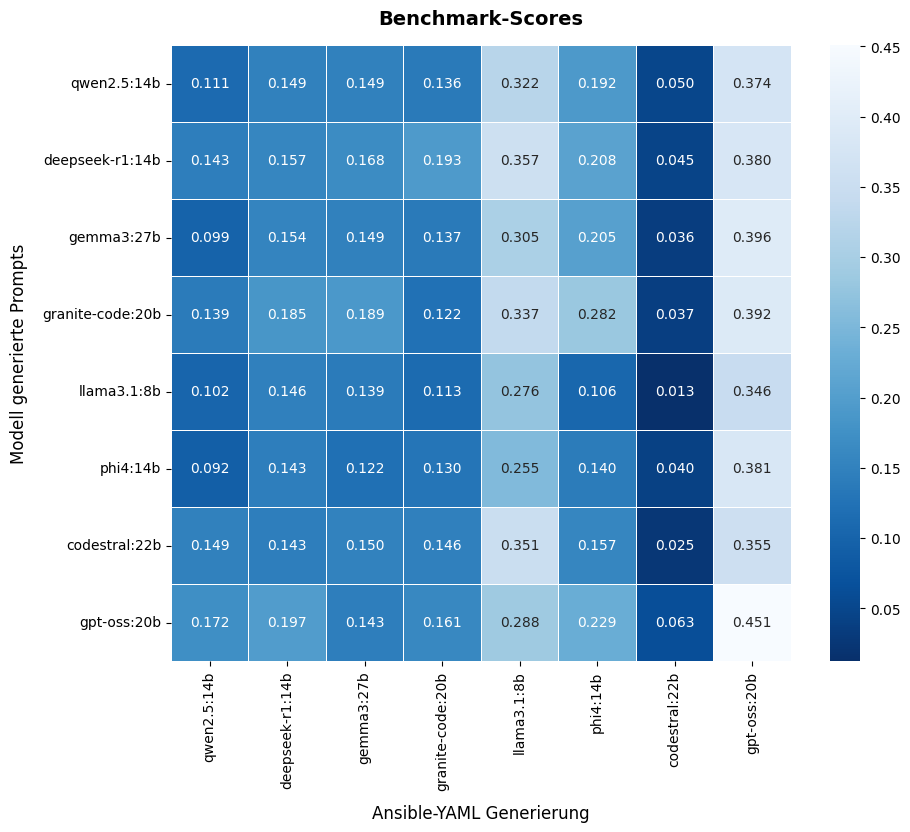

In [55]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_benchmark_scores, annot=True, fmt=".3f", cmap="Blues_r", linewidths=0.5 )
plt.title("Benchmark-Scores", fontsize=14, pad=15, weight='bold')
plt.xlabel("Ansible-YAML Generierung", fontsize=12, labelpad=10)
plt.ylabel("Modell generierte Prompts", fontsize=12, labelpad=10)
plt.show()

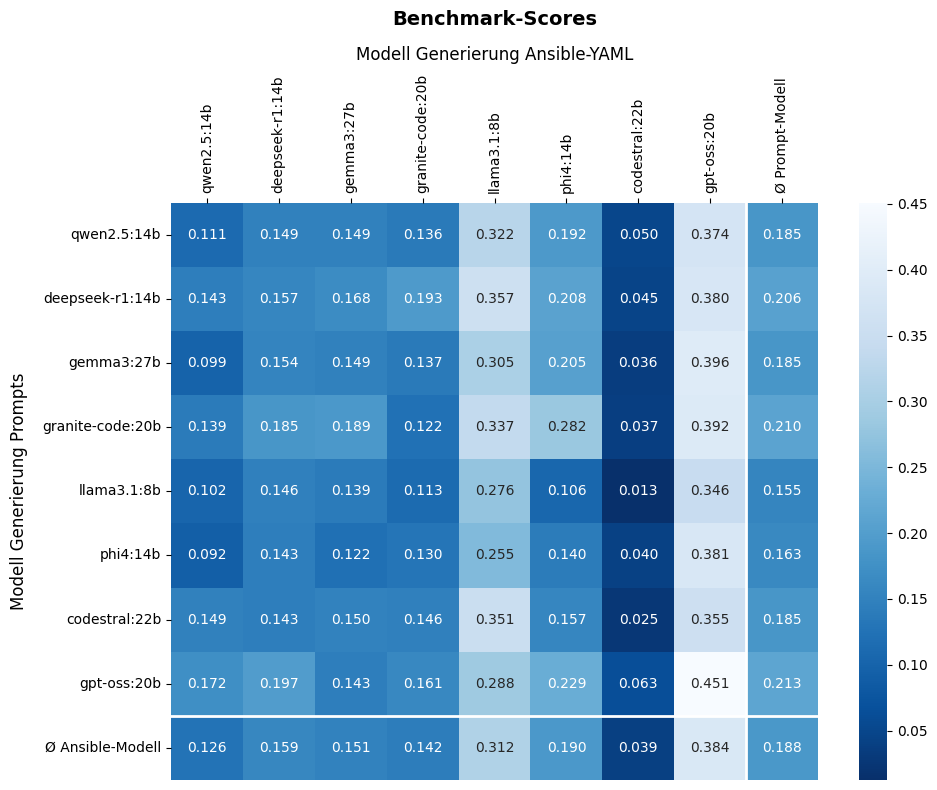

In [56]:
df_benchmark_scores_extended = df_benchmark_scores.copy()
df_benchmark_scores_extended["Ø Prompt-Modell"] = df_benchmark_scores_extended.mean(axis=1)
df_benchmark_scores_extended.loc["Ø Ansible-Modell"] = df_benchmark_scores_extended.mean(axis=0)

plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    df_benchmark_scores_extended,
    annot=True,
    fmt=".3f",
    cmap="Blues_r",
    cbar=True,
)

ax.set_title("Benchmark-Scores", fontsize=14, pad=15, weight='bold')
ax.set_xlabel("Modell Generierung Ansible-YAML", fontsize=12, labelpad=10)
ax.set_ylabel("Modell Generierung Prompts", fontsize=12, labelpad=10)

ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()

plt.xticks(rotation=90)
n = len(df_benchmark_scores.columns)  
ax.axhline(n, color='white', lw=2)    
ax.axvline(n, color='white', lw=2)   

plt.tight_layout()
plt.savefig("heatmap_benchmark_scores_extended.png", dpi=300, bbox_inches='tight')
plt.show()



# Analysis of Ansible-Lint-Scores

In [57]:
print(df_ansiblelint_scores.describe())

       qwen2.5:14b  deepseek-r1:14b  gemma3:27b  granite-code:20b  \
count     8.000000         8.000000    8.000000          8.000000   
mean      1.050438         1.045913    1.041700          1.020888   
std       0.050640         0.045757    0.039192          0.024012   
min       1.000000         1.007600    1.000000          1.000000   
25%       1.026125         1.014000    1.008450          1.005675   
50%       1.037200         1.026600    1.045000          1.010750   
75%       1.050075         1.061450    1.052050          1.028450   
max       1.166700         1.135900    1.122200          1.071900   

       llama3.1:8b  phi4:14b  codestral:22b  gpt-oss:20b  
count     8.000000  8.000000       8.000000     8.000000  
mean      1.467125  1.073700       1.213450     1.045037  
std       0.047782  0.065508       0.142599     0.065369  
min       1.392900  1.023800       1.058800     1.007700  
25%       1.450975  1.032150       1.141150     1.014800  
50%       1.473100  1.05

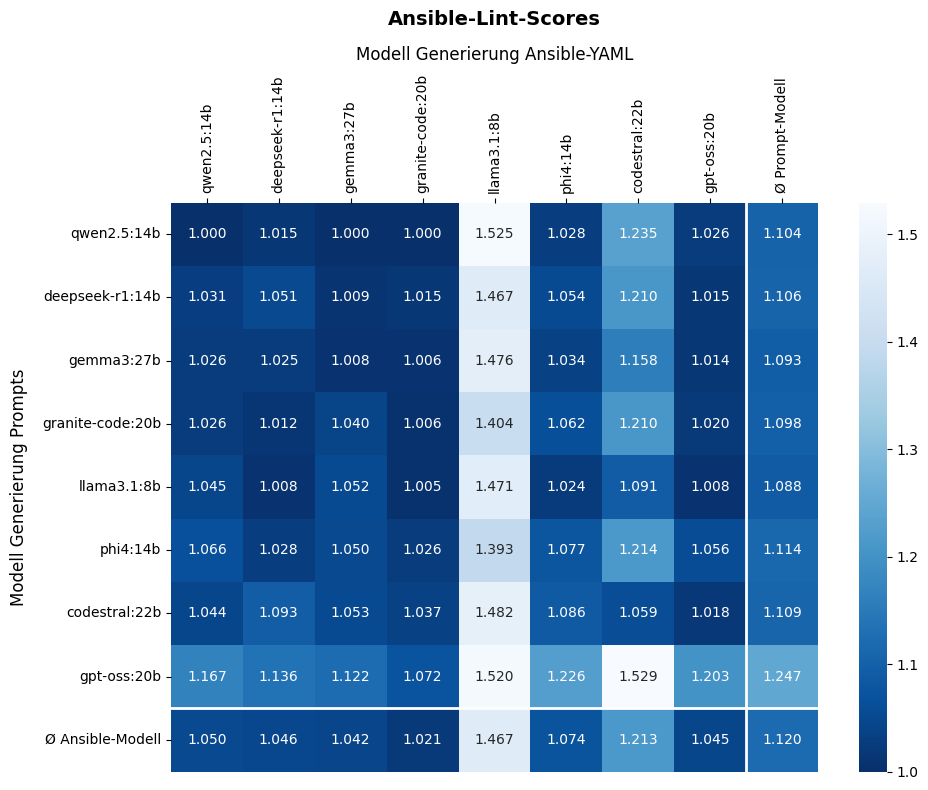

In [58]:
df_ansiblelint_scores_extended = df_ansiblelint_scores.copy()
df_ansiblelint_scores_extended["Ø Prompt-Modell"] = df_ansiblelint_scores_extended.mean(axis=1)
df_ansiblelint_scores_extended.loc["Ø Ansible-Modell"] = df_ansiblelint_scores_extended.mean(axis=0)

plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    df_ansiblelint_scores_extended,
    annot=True,
    fmt=".3f",
    cmap="Blues_r",
    cbar=True,
)

ax.set_title("Ansible-Lint-Scores", fontsize=14, pad=15, weight='bold')
ax.set_xlabel("Modell Generierung Ansible-YAML", fontsize=12, labelpad=10)
ax.set_ylabel("Modell Generierung Prompts", fontsize=12, labelpad=10)

ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()

plt.xticks(rotation=90)
n = len(df_benchmark_scores.columns)  
ax.axhline(n, color='white', lw=2)    
ax.axvline(n, color='white', lw=2)   

plt.tight_layout()
plt.savefig("heatmap_ansiblelint_scores_extended.png", dpi=300, bbox_inches='tight')
plt.show()



# Analysis of YAMLLint-Scores

In [59]:
print(df_ansiblelint_scores.describe())

       qwen2.5:14b  deepseek-r1:14b  gemma3:27b  granite-code:20b  \
count     8.000000         8.000000    8.000000          8.000000   
mean      1.050438         1.045913    1.041700          1.020888   
std       0.050640         0.045757    0.039192          0.024012   
min       1.000000         1.007600    1.000000          1.000000   
25%       1.026125         1.014000    1.008450          1.005675   
50%       1.037200         1.026600    1.045000          1.010750   
75%       1.050075         1.061450    1.052050          1.028450   
max       1.166700         1.135900    1.122200          1.071900   

       llama3.1:8b  phi4:14b  codestral:22b  gpt-oss:20b  
count     8.000000  8.000000       8.000000     8.000000  
mean      1.467125  1.073700       1.213450     1.045037  
std       0.047782  0.065508       0.142599     0.065369  
min       1.392900  1.023800       1.058800     1.007700  
25%       1.450975  1.032150       1.141150     1.014800  
50%       1.473100  1.05

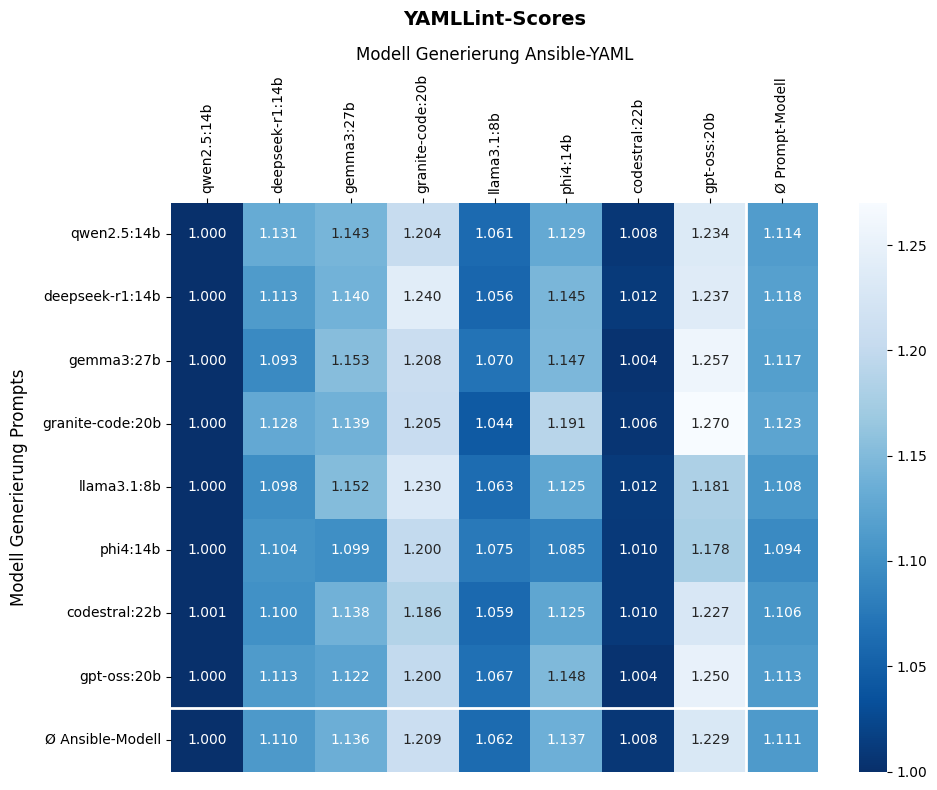

In [60]:
df_yamllint_scores_extended = df_yamllint_scores.copy()
df_yamllint_scores_extended["Ø Prompt-Modell"] = df_yamllint_scores_extended.mean(axis=1)
df_yamllint_scores_extended.loc["Ø Ansible-Modell"] = df_yamllint_scores_extended.mean(axis=0)

plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    df_yamllint_scores_extended,
    annot=True,
    fmt=".3f",
    cmap="Blues_r",
    cbar=True,
)

ax.set_title("YAMLLint-Scores", fontsize=14, pad=15, weight='bold')
ax.set_xlabel("Modell Generierung Ansible-YAML", fontsize=12, labelpad=10)
ax.set_ylabel("Modell Generierung Prompts", fontsize=12, labelpad=10)

ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()

plt.xticks(rotation=90)
n = len(df_benchmark_scores.columns)  
ax.axhline(n, color='white', lw=2)    
ax.axvline(n, color='white', lw=2)   

plt.tight_layout()
plt.savefig("heatmap_yamllint_scores_extended.png", dpi=300, bbox_inches='tight')
plt.show()



# Analysis of File-Information 

In [61]:
# Neue Spalten hinzufügen
df_file_information["Yamllint passed"] = (
    df_file_information["Ansiblelint failed"] + 
    df_file_information["Molecule failed"] + 
    df_file_information["Molecule passed"]
)

df_file_information["Ansiblelint passed"] = (
    df_file_information["Molecule failed"] + 
    df_file_information["Molecule passed"]
)

df_file_information.head()


,Datei,Yamllint failed,Ansiblelint failed,Molecule failed,Molecule passed,Total runs,File size (chars),Yamllint passed,Ansiblelint passed
0,ansible-role-cadvisor/tasks/main.yml,41,5,17,1,64,1696,23,18
1,ansible-role-pip/tasks/main.yml,29,5,26,4,64,880,35,30
2,ansible-role-epel-buluma/tasks/main.yml,39,4,18,3,64,756,25,21
3,ansible-role-mysql/tasks/main.yml,38,9,17,0,64,2615,26,17
4,ansible-role-bootstrap-buluma/tasks/main.yml,36,13,15,0,64,2122,28,15


In [62]:
print(df_file_information.describe())

       Yamllint failed  Ansiblelint failed  Molecule failed  Molecule passed  \
count       100.000000          100.000000       100.000000       100.000000   
mean         32.980000            5.650000        18.420000         6.950000   
std          13.913862            3.688297        11.110265        10.682162   
min           6.000000            0.000000         0.000000         0.000000   
25%          21.500000            3.000000        11.000000         0.000000   
50%          35.500000            5.000000        17.000000         3.000000   
75%          43.000000            8.000000        27.250000        10.000000   
max          61.000000           19.000000        41.000000        53.000000   

       Total runs  File size (chars)  Yamllint passed  Ansiblelint passed  
count       100.0         100.000000       100.000000           100.00000  
mean         64.0        1661.370000        31.020000            25.37000  
std           0.0        1807.581383        13.9138

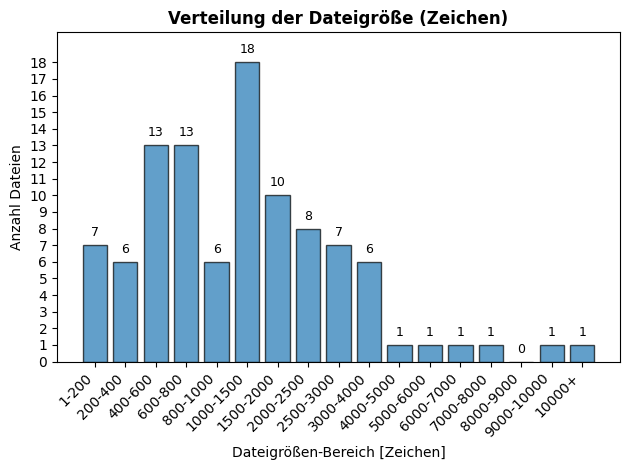

In [63]:
import matplotlib.pyplot as plt
import numpy as np

data = df_file_information["File size (chars)"]

# Variable Bins
bins = [1, 200, 400, 600, 800, 1000, 1500, 2000, 2500, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, max(data)+1]

# Histogramm berechnen (ohne direkt zu plotten)
counts, _ = np.histogram(data, bins=bins)

# Balken gleich breit zeichnen (x=Bin-Index)
bin_centers = np.arange(len(counts))
plt.bar(bin_centers, counts, width=0.8, edgecolor='black', alpha=0.7)

# Labels über den Balken
for count, x in zip(counts, bin_centers):
    plt.text(x, count + max(counts)*0.02, f"{int(count)}", ha='center', va='bottom', fontsize=9)

# X-Achse: echte Bin-Bereiche als Labels
bin_labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]
bin_labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]
bin_labels[-1] = f"{int(bins[-2])}+"
plt.xticks(bin_centers, bin_labels, rotation=45, ha='right')

# Gitterlinien
#plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Y-Achse in ganzen Zahlen
plt.yticks(np.arange(0, max(counts)+1, 1))

plt.title("Verteilung der Dateigröße (Zeichen)", weight='bold')
plt.xlabel("Dateigrößen-Bereich [Zeichen]")
plt.ylabel("Anzahl Dateien")
plt.ylim(0, max(counts)*1.1)

plt.tight_layout()
plt.savefig("file_size_distribution_equal_width.png", dpi=300, bbox_inches='tight')
plt.show()


/tmp/ipykernel_3773678/1479813013.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=corrs.values, y=corrs.index, palette="Blues", orient="h")


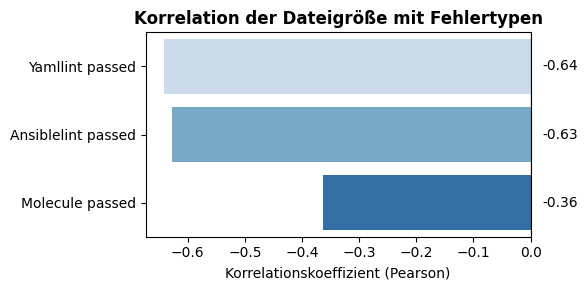

Yamllint passed      -0.641591
Ansiblelint passed   -0.627754
Molecule passed      -0.363271
Name: File size (chars), dtype: float64


In [64]:
corrs = df_file_information[[ 
    "File size (chars)",
    "Yamllint passed",
    "Ansiblelint passed",
    "Molecule passed"
]].corr()["File size (chars)"].drop("File size (chars)")

corrs = corrs.sort_values(ascending=True)

plt.figure(figsize=(6, 3))
ax = sns.barplot(x=corrs.values, y=corrs.index, palette="Blues", orient="h")

plt.axvline(0, color='black', linewidth=0.8)
plt.title("Korrelation der Dateigröße mit Fehlertypen", weight='bold')
plt.xlabel("Korrelationskoeffizient (Pearson)")
plt.ylabel("")

for i, v in enumerate(corrs.values):
    if v >= 0:
        ax.text(-0.02, i, f"{v:.2f}", color='black', va='center', ha='right')
    else:
        ax.text(0.02, i, f"{v:.2f}", color='black', va='center', ha='left')

plt.tight_layout()
plt.savefig("correlation_file_size.png", dpi=300, bbox_inches='tight')

plt.show()

print(corrs)



| Stage              | Korrelationswert | Interpretation |
|--------------------|------------------|----------------|
| **Yamllint passed** | **-0.64** | Deutlicher negativer Zusammenhang – je größer die Datei, desto seltener besteht sie Yamllint. Größere Dateien haben häufiger Format- oder Syntaxfehler. |
| **Ansiblelint passed** | **-0.63** | Ebenfalls stark negativ – größere Dateien verstoßen häufiger gegen Ansible-Lint-Regeln. Das deutet auf komplexeren oder weniger konsistenten Code hin. |
| **Molecule passed** | **-0.36** | Mäßig negativer Zusammenhang – größere Dateien bestehen Molecule-Tests seltener, aber der Effekt ist schwächer, da hier mehr Faktoren mitspielen. |


In [65]:
# DataFrames erstellen
df_yaml = pd.DataFrame(yamllint_scores)
df_ansible = pd.DataFrame(ansiblelint_scores)

# Beide DataFrames in long-format bringen
df_yaml_long = df_yaml.melt(var_name="Prompt-Modell", value_name="YAMLLint-Score")
df_ansible_long = df_ansible.melt(var_name="Prompt-Modell", value_name="AnsibleLint-Score")

# Zusammenführen
df_combined = pd.merge(df_yaml_long, df_ansible_long, on=["Prompt-Modell", df_yaml_long.index.name])

# Pearson-Korrelation berechnen
correlation = df_combined["YAMLLint-Score"].corr(df_combined["AnsibleLint-Score"])
print("Pearson-Korrelation Yamllint vs Ansiblelint:", correlation)


Pearson-Korrelation Yamllint vs Ansiblelint: -0.4012089391828879


/tmp/ipykernel_3773678/459343608.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rel_success.index, y=rel_success.values, palette="Blues")


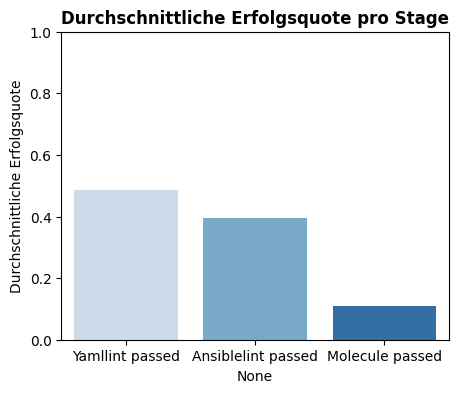

In [66]:
stages_passed = ["Yamllint passed", "Ansiblelint passed", "Molecule passed"]

# Balkendiagramm: relative Erfolgsquote
rel_success = df_file_information[stages_passed].div(df_file_information["Total runs"], axis=0).mean()
plt.figure(figsize=(5,4))
sns.barplot(x=rel_success.index, y=rel_success.values, palette="Blues")
plt.ylabel("Durchschnittliche Erfolgsquote")
plt.title("Durchschnittliche Erfolgsquote pro Stage", weight='bold')
plt.ylim(0,1)
plt.savefig("average_success_rate.png", dpi=300, bbox_inches='tight')

plt.show()




Die Grafik zeigt den durchschnittlichen Anteil erfolgreich bestandener Tests über alle untersuchten Dateien hinweg.  
Sie verdeutlicht, in welchen Stufen der Ansible-Workflow (Yamllint → Ansiblelint → Molecule) die meisten Fehler auftreten.  

Ein höherer Balken bedeutet, dass Dateien diese Stage häufiger bestehen.  
Typischerweise liegt die Erfolgsquote bei **Yamllint** am höchsten und nimmt über **Ansiblelint** bis **Molecule** deutlich ab, was darauf hindeutet,  
dass die Anforderungen in späteren Testphasen komplexer und fehleranfälliger sind.

/tmp/ipykernel_3773678/1848037175.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rel_failed.index, y=rel_failed.values, palette="Blues")


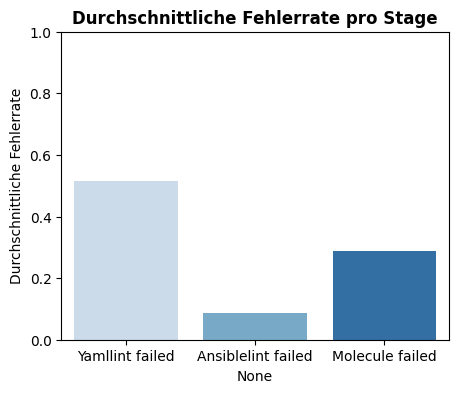

In [67]:
stages_failed = ["Yamllint failed", "Ansiblelint failed", "Molecule failed"]
rel_failed = df_file_information[stages_failed].div(df_file_information["Total runs"], axis=0).mean()
plt.figure(figsize=(5,4))
sns.barplot(x=rel_failed.index, y=rel_failed.values, palette="Blues")
plt.ylabel("Durchschnittliche Fehlerrate")
plt.title("Durchschnittliche Fehlerrate pro Stage", weight='bold')
plt.ylim(0,1)
plt.savefig("average_failed_rate.png", dpi=300, bbox_inches='tight')

plt.show()




Die Grafik zeigt den durchschnittlichen Anteil fehlgeschlagener Durchläufe in den drei Teststufen *Yamllint*, *Ansiblelint* und *Molecule*.  
Ein höherer Balken steht für eine höhere Fehlerrate und deutet darauf hin, dass in dieser Stage häufiger Probleme auftreten.  

Die Darstellung macht sichtbar, in welchen Phasen des Ansible-Workflows die meisten Fehler entstehen – typischerweise in den frühen Stufen wie *Yamllint*,  
wo Format- und Syntaxfehler am häufigsten sind. Dadurch lässt sich gezielt ableiten, welche Bereiche in der Codequalität oder im Linting-Prozess priorisiert verbessert werden sollten.

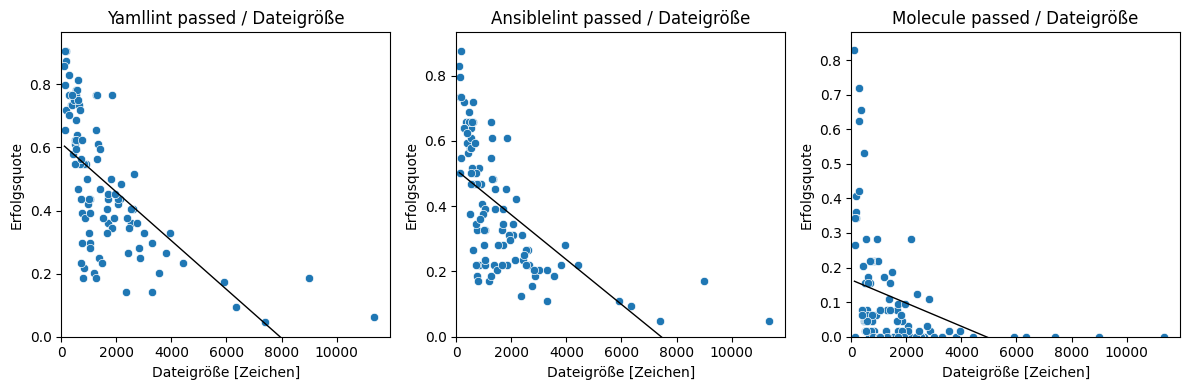

In [68]:
plt.figure(figsize=(12,4))
for i, stage in enumerate(stages_passed,1):
    plt.subplot(1,3,i)
    sns.scatterplot(
        x=df_file_information["File size (chars)"], 
        y=df_file_information[stage]/df_file_information["Total runs"]
    )
    sns.regplot(
        x=df_file_information["File size (chars)"], 
        y=df_file_information[stage]/df_file_information["Total runs"], 
        scatter=False, color='black', ci=None, line_kws={"linewidth": 1}
    )
    plt.title(stage + " / Dateigröße")
    plt.xlabel("Dateigröße [Zeichen]")
    plt.ylabel("Erfolgsquote")

    plt.xlim(left=0)
    plt.ylim(bottom=0)
plt.tight_layout()
plt.savefig("successrate_vs_filesize.png", dpi=300, bbox_inches='tight')

plt.show()




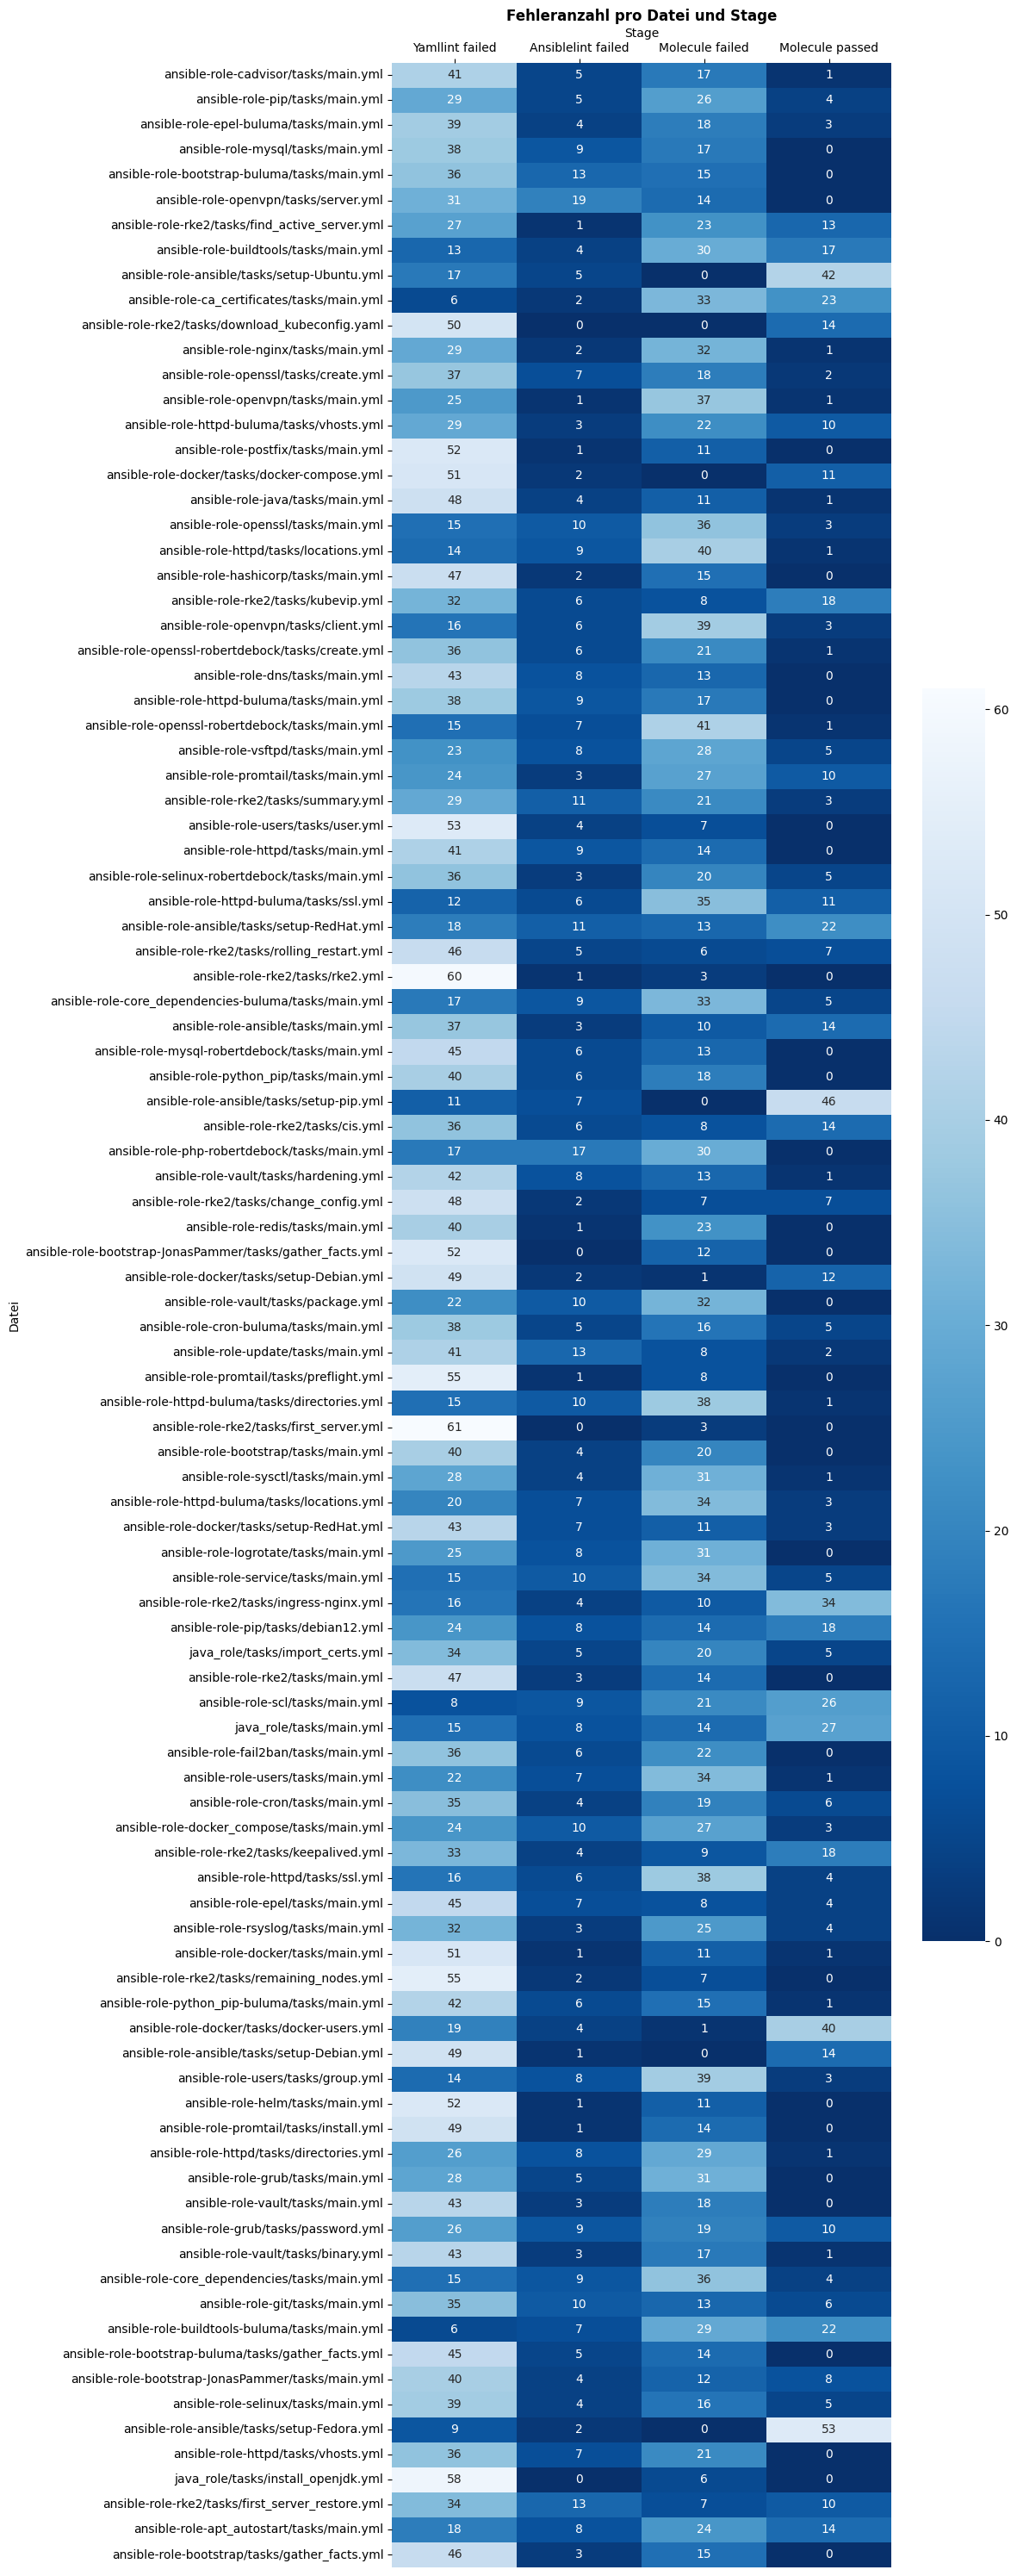

In [69]:
heat_data = df_file_information[stages_failed + ["Molecule passed"]]
plt.figure(figsize=(12,30))

ax = sns.heatmap(
    heat_data, 
    annot=True, 
    fmt="d", 
    cmap="Blues_r", 
    yticklabels=df_file_information["Datei"],
    cbar_kws={"shrink": 0.5}  # Farbbalken auf 50% der Höhe
)

# Spaltenbeschriftungen nach oben verschieben
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.title("Fehleranzahl pro Datei und Stage", weight='bold')
plt.ylabel("Datei")
plt.xlabel("Stage")
plt.tight_layout()
plt.savefig("heatmap_stage_counter.png", dpi=300, bbox_inches='tight')

plt.show()



/tmp/ipykernel_3773678/859503638.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  failure_ratios = df_file_information.groupby(bins)[stages_failed].sum() / df_file_information.groupby(bins).size().values.reshape(-1,1)
/tmp/ipykernel_3773678/859503638.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  failure_ratios = df_file_information.groupby(bins)[stages_failed].sum() / df_file_information.groupby(bins).size().values.reshape(-1,1)


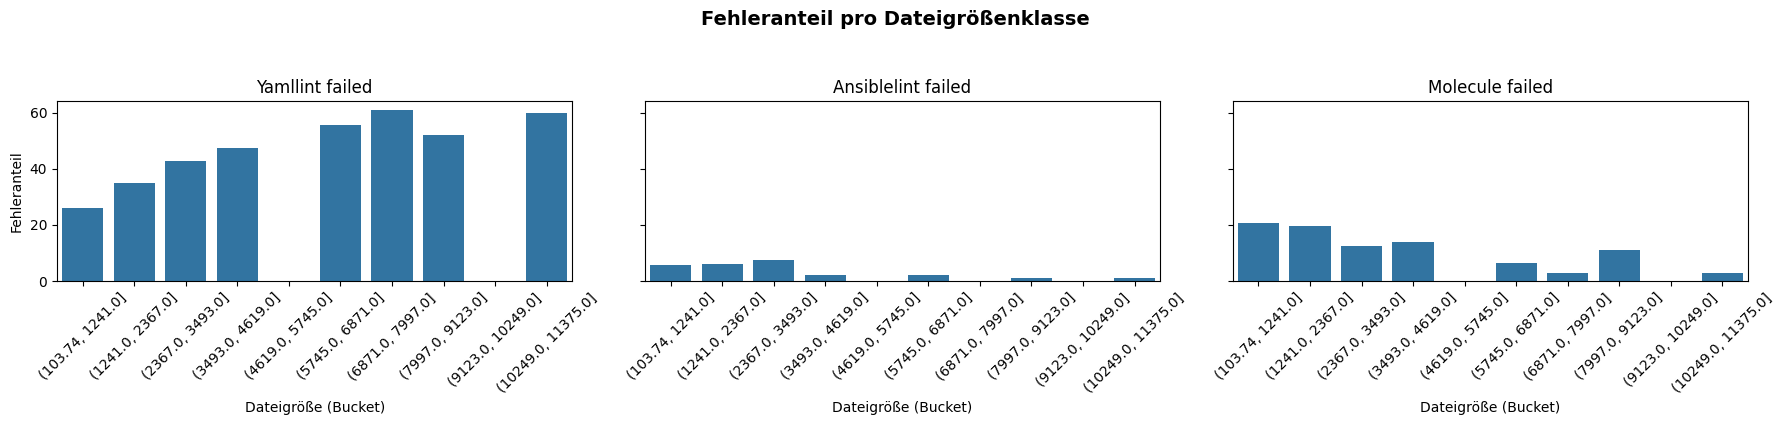

In [70]:
bins = pd.cut(df_file_information["File size (chars)"], bins=10)
failure_ratios = df_file_information.groupby(bins)[stages_failed].sum() / df_file_information.groupby(bins).size().values.reshape(-1,1)

fig, axes = plt.subplots(1,3, figsize=(18,4), sharey=True)
for i, stage in enumerate(stages_failed):
    sns.barplot(
        x=failure_ratios.index.astype(str), 
        y=failure_ratios[stage], 
        ax=axes[i], 
        color="tab:blue"
    )
    axes[i].set_title(stage)
    axes[i].set_xlabel("Dateigröße (Bucket)")
    if i==0:
        axes[i].set_ylabel("Fehleranteil")
    axes[i].tick_params(axis="x", rotation=45)
plt.suptitle("Fehleranteil pro Dateigrößenklasse", fontsize=14, weight='bold', y=1.05)
plt.tight_layout()
plt.show()



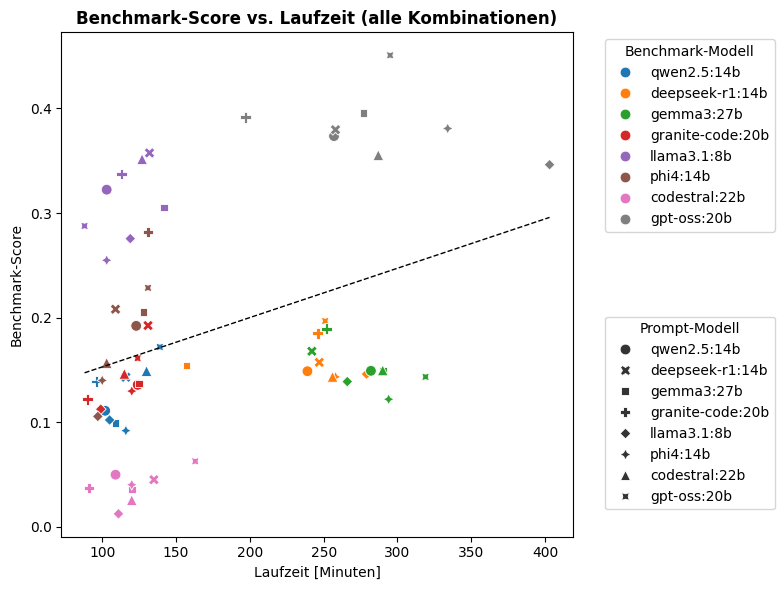

In [71]:
scores_long = df_benchmark_scores.reset_index().melt(
    id_vars=df_benchmark_scores.index.name or "index",
    var_name="Benchmark-Modell",
    value_name="Score"
)
durations_long = df_duration_runs.reset_index().melt(
    id_vars=df_duration_runs.index.name or "index",
    var_name="Benchmark-Modell",
    value_name="Laufzeit (min)"
)

# Gleiche Spaltennamen für Join
scores_long.rename(columns={scores_long.columns[0]: "Prompt-Modell"}, inplace=True)
durations_long.rename(columns={durations_long.columns[0]: "Prompt-Modell"}, inplace=True)

# Kombinieren über beide Dimensionen (Prompt + Benchmark)
df_combined = pd.merge(scores_long, durations_long, on=["Prompt-Modell", "Benchmark-Modell"])

plt.figure(figsize=(8, 6))
scatter = sns.scatterplot(
    data=df_combined,
    x="Laufzeit (min)",
    y="Score",
    hue="Benchmark-Modell",
    style="Prompt-Modell",
    s=60
)

sns.regplot(
    data=df_combined,
    x="Laufzeit (min)",
    y="Score",
    scatter=False,
    color="black",
    line_kws={"linewidth": 1, "linestyle": "--"},
    ci=None
)

plt.title("Benchmark-Score vs. Laufzeit (alle Kombinationen)", weight='bold')
plt.xlabel("Laufzeit [Minuten]")
plt.ylabel("Benchmark-Score")

# Legenden getrennt anzeigen
hue_legend = scatter.legend_.get_texts()
handles, labels = scatter.get_legend_handles_labels()

# Anzahl der Hue-Elemente (Benchmark-Modelle)
num_hue = df_combined["Benchmark-Modell"].nunique()

# Getrennte Handles für beide Gruppen
handles_hue = handles[1:num_hue + 1]
labels_hue = labels[1:num_hue + 1]

handles_style = handles[num_hue + 2:]
labels_style = labels[num_hue + 2:]

# Zwei separate Legenden erstellen
legend1 = plt.legend(handles_hue, labels_hue, title="Benchmark-Modell", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.gca().add_artist(legend1)

plt.legend(handles_style, labels_style, title="Prompt-Modell", bbox_to_anchor=(1.05, 0.45), loc="upper left")

plt.tight_layout()
plt.savefig("scatter_plot_runtime_benchmark_score.png", dpi=300, bbox_inches='tight')

plt.show()



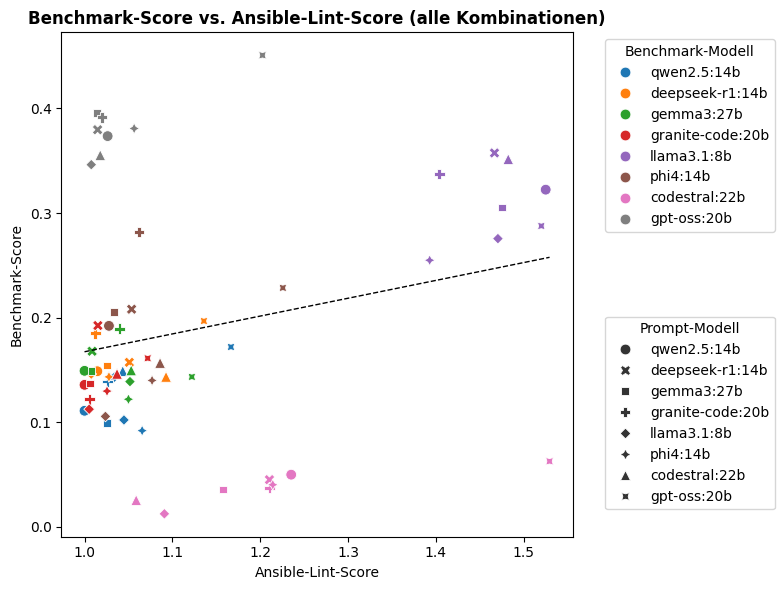

In [72]:
scores_long = df_benchmark_scores.reset_index().melt(
    id_vars=df_benchmark_scores.index.name or "index",
    var_name="Benchmark-Modell",
    value_name="Benchmark-Score"
)
ansiblelint_scores_long = df_ansiblelint_scores.reset_index().melt(
    id_vars=df_ansiblelint_scores.index.name or "index",
    var_name="Benchmark-Modell",
    value_name="Ansible-Lint-Score"
)

# Gleiche Spaltennamen für Join
scores_long.rename(columns={scores_long.columns[0]: "Prompt-Modell"}, inplace=True)
ansiblelint_scores_long.rename(columns={ansiblelint_scores_long.columns[0]: "Prompt-Modell"}, inplace=True)

# Kombinieren über beide Dimensionen (Prompt + Benchmark)
df_combined = pd.merge(scores_long, ansiblelint_scores_long, on=["Prompt-Modell", "Benchmark-Modell"])

plt.figure(figsize=(8, 6))
scatter = sns.scatterplot(
    data=df_combined,
    x="Ansible-Lint-Score",
    y="Benchmark-Score",
    hue="Benchmark-Modell",
    style="Prompt-Modell",
    s=60
)

sns.regplot(
    data=df_combined,
    x="Ansible-Lint-Score",
    y="Benchmark-Score",
    scatter=False,
    color="black",
    line_kws={"linewidth": 1, "linestyle": "--"},
    ci=None
)

plt.title("Benchmark-Score vs. Ansible-Lint-Score (alle Kombinationen)", weight='bold')
plt.xlabel("Ansible-Lint-Score")
plt.ylabel("Benchmark-Score")

# Legenden getrennt anzeigen
hue_legend = scatter.legend_.get_texts()
handles, labels = scatter.get_legend_handles_labels()

# Anzahl der Hue-Elemente (Benchmark-Modelle)
num_hue = df_combined["Benchmark-Modell"].nunique()

# Getrennte Handles für beide Gruppen
handles_hue = handles[1:num_hue + 1]
labels_hue = labels[1:num_hue + 1]

handles_style = handles[num_hue + 2:]
labels_style = labels[num_hue + 2:]

# Zwei separate Legenden erstellen
legend1 = plt.legend(handles_hue, labels_hue, title="Benchmark-Modell", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.gca().add_artist(legend1)

plt.legend(handles_style, labels_style, title="Prompt-Modell", bbox_to_anchor=(1.05, 0.45), loc="upper left")

plt.tight_layout()
plt.savefig("scatter_plot_ansiblelint_benchmark_score.png", dpi=300, bbox_inches='tight')

plt.show()

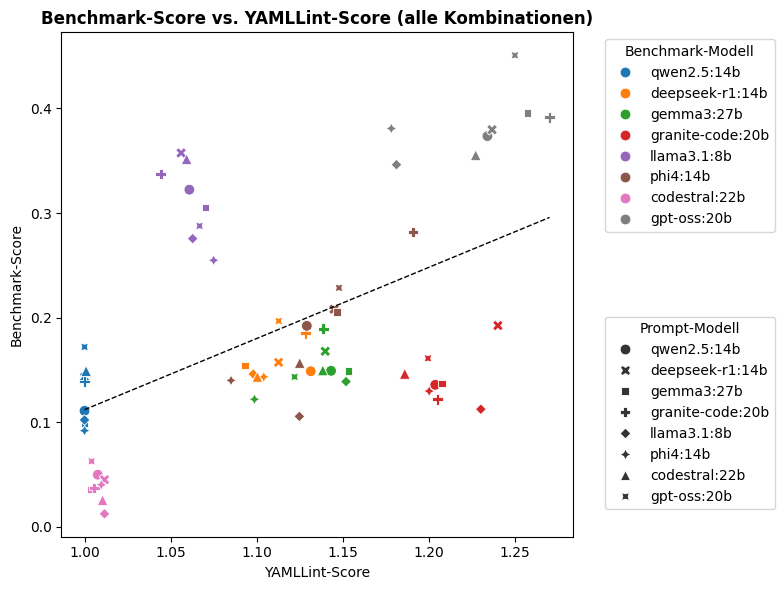

In [73]:
scores_long = df_benchmark_scores.reset_index().melt(
    id_vars=df_benchmark_scores.index.name or "index",
    var_name="Benchmark-Modell",
    value_name="Benchmark-Score"
)
yamllint_scores_long = df_yamllint_scores.reset_index().melt(
    id_vars=df_yamllint_scores.index.name or "index",
    var_name="Benchmark-Modell",
    value_name="YAMLLint-Score"
)

# Gleiche Spaltennamen für Join
scores_long.rename(columns={scores_long.columns[0]: "Prompt-Modell"}, inplace=True)
yamllint_scores_long.rename(columns={yamllint_scores_long.columns[0]: "Prompt-Modell"}, inplace=True)

# Kombinieren über beide Dimensionen (Prompt + Benchmark)
df_combined = pd.merge(scores_long, yamllint_scores_long, on=["Prompt-Modell", "Benchmark-Modell"])

plt.figure(figsize=(8, 6))
scatter = sns.scatterplot(
    data=df_combined,
    x="YAMLLint-Score",
    y="Benchmark-Score",
    hue="Benchmark-Modell",
    style="Prompt-Modell",
    s=60
)

sns.regplot(
    data=df_combined,
    x="YAMLLint-Score",
    y="Benchmark-Score",
    scatter=False,
    color="black",
    line_kws={"linewidth": 1, "linestyle": "--"},
    ci=None
)

plt.title("Benchmark-Score vs. YAMLLint-Score (alle Kombinationen)", weight='bold')
plt.xlabel("YAMLLint-Score")
plt.ylabel("Benchmark-Score")

# Legenden getrennt anzeigen
hue_legend = scatter.legend_.get_texts()
handles, labels = scatter.get_legend_handles_labels()

# Anzahl der Hue-Elemente (Benchmark-Modelle)
num_hue = df_combined["Benchmark-Modell"].nunique()

# Getrennte Handles für beide Gruppen
handles_hue = handles[1:num_hue + 1]
labels_hue = labels[1:num_hue + 1]

handles_style = handles[num_hue + 2:]
labels_style = labels[num_hue + 2:]

# Zwei separate Legenden erstellen
legend1 = plt.legend(handles_hue, labels_hue, title="Benchmark-Modell", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.gca().add_artist(legend1)

plt.legend(handles_style, labels_style, title="Prompt-Modell", bbox_to_anchor=(1.05, 0.45), loc="upper left")

plt.tight_layout()
plt.savefig("scatter_plot_yamllint_benchmark_score.png", dpi=300, bbox_inches='tight')

plt.show()

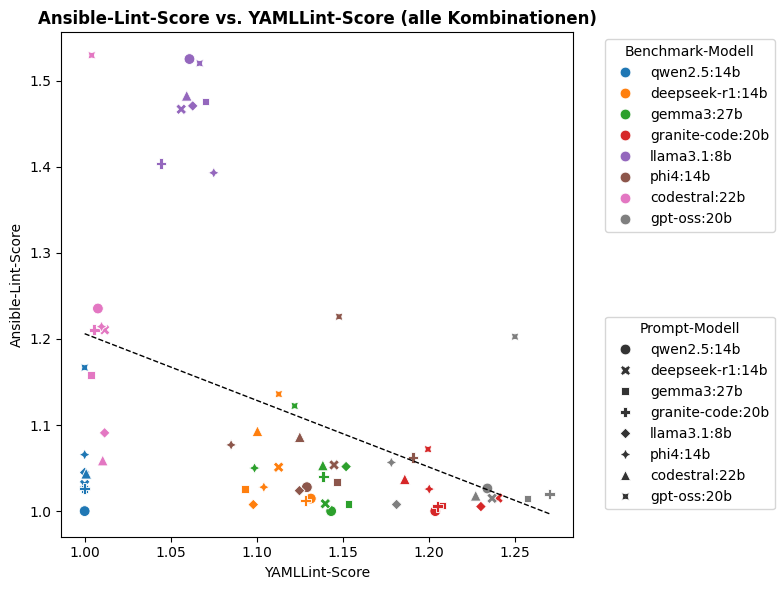

In [74]:
ansiblelint_scores_long = df_ansiblelint_scores.reset_index().melt(
    id_vars=df_ansiblelint_scores.index.name or "index",
    var_name="Benchmark-Modell",
    value_name="Ansible-Lint-Score"
)
yamllint_scores_long = df_yamllint_scores.reset_index().melt(
    id_vars=df_yamllint_scores.index.name or "index",
    var_name="Benchmark-Modell",
    value_name="YAMLLint-Score"
)

# Gleiche Spaltennamen für Join
ansiblelint_scores_long.rename(columns={ansiblelint_scores_long.columns[0]: "Prompt-Modell"}, inplace=True)
yamllint_scores_long.rename(columns={yamllint_scores_long.columns[0]: "Prompt-Modell"}, inplace=True)

# Kombinieren über beide Dimensionen (Prompt + Benchmark)
df_combined = pd.merge(ansiblelint_scores_long, yamllint_scores_long, on=["Prompt-Modell", "Benchmark-Modell"])

plt.figure(figsize=(8, 6))
scatter = sns.scatterplot(
    data=df_combined,
    x="YAMLLint-Score",
    y="Ansible-Lint-Score",
    hue="Benchmark-Modell",
    style="Prompt-Modell",
    s=60
)

sns.regplot(
    data=df_combined,
    x="YAMLLint-Score",
    y="Ansible-Lint-Score",
    scatter=False,
    color="black",
    line_kws={"linewidth": 1, "linestyle": "--"},
    ci=None
)

plt.title("Ansible-Lint-Score vs. YAMLLint-Score (alle Kombinationen)", weight='bold')
plt.xlabel("YAMLLint-Score")
plt.ylabel("Ansible-Lint-Score")

# Legenden getrennt anzeigen
hue_legend = scatter.legend_.get_texts()
handles, labels = scatter.get_legend_handles_labels()

# Anzahl der Hue-Elemente (Benchmark-Modelle)
num_hue = df_combined["Benchmark-Modell"].nunique()

# Getrennte Handles für beide Gruppen
handles_hue = handles[1:num_hue + 1]
labels_hue = labels[1:num_hue + 1]

handles_style = handles[num_hue + 2:]
labels_style = labels[num_hue + 2:]

# Zwei separate Legenden erstellen
legend1 = plt.legend(handles_hue, labels_hue, title="Benchmark-Modell", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.gca().add_artist(legend1)

plt.legend(handles_style, labels_style, title="Prompt-Modell", bbox_to_anchor=(1.05, 0.45), loc="upper left")

plt.tight_layout()
plt.savefig("scatter_plot_yamllint_ansible_lint_score.png", dpi=300, bbox_inches='tight')

plt.show()

Korrelation (Pearson) zwischen yamllint und ansiblelint: -0.4484


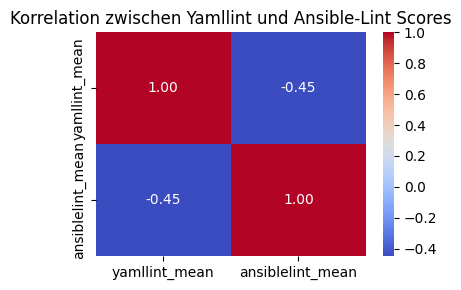

/tmp/ipykernel_3773678/59420103.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(df_combined.yamllint_mean[i] + 0.001, df_combined.ansiblelint_mean[i], label, fontsize=8)


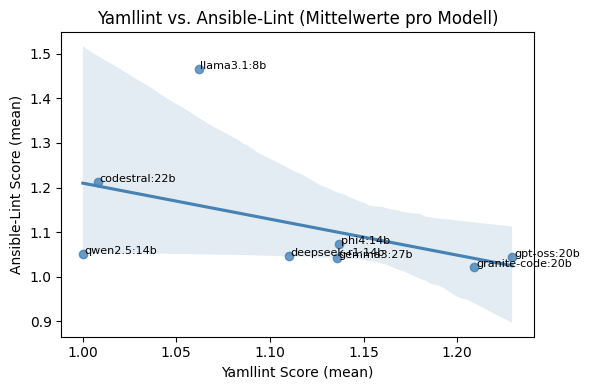

In [75]:
# Mittelwerte pro Modell
mean_yamllint = df_yamllint_scores.mean()
mean_ansiblelint = df_ansiblelint_scores.mean()

# Kombinierte DataFrame
df_combined = pd.DataFrame({
    'yamllint_mean': mean_yamllint,
    'ansiblelint_mean': mean_ansiblelint
})

# --- Korrelation berechnen ---
corr_value = df_combined.corr().iloc[0,1]
print(f"Korrelation (Pearson) zwischen yamllint und ansiblelint: {corr_value:.4f}")

# --- Heatmap ---
plt.figure(figsize=(4,3))
sns.heatmap(df_combined.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korrelation zwischen Yamllint und Ansible-Lint Scores")
plt.tight_layout()
plt.show()

# --- Scatterplot ---
plt.figure(figsize=(6,4))
sns.regplot(data=df_combined, x="yamllint_mean", y="ansiblelint_mean", marker='o', color='steelblue')
for i, label in enumerate(df_combined.index):
    plt.text(df_combined.yamllint_mean[i] + 0.001, df_combined.ansiblelint_mean[i], label, fontsize=8)
plt.title("Yamllint vs. Ansible-Lint (Mittelwerte pro Modell)")
plt.xlabel("Yamllint Score (mean)")
plt.ylabel("Ansible-Lint Score (mean)")
plt.tight_layout()
plt.show()

/tmp/ipykernel_3773678/4100198884.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '4' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_formatted.loc[r, c] = f"{int(round(val))}"
/tmp/ipykernel_3773678/4100198884.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '4' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_formatted.loc[r, c] = f"{int(round(val))}"
/tmp/ipykernel_3773678/4100198884.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '8' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_formatted.loc[r, c] = f"{int(round(val))}"
/tmp/ipykernel_3773678/4100198884.py:17: FutureWarning: Setting an ite

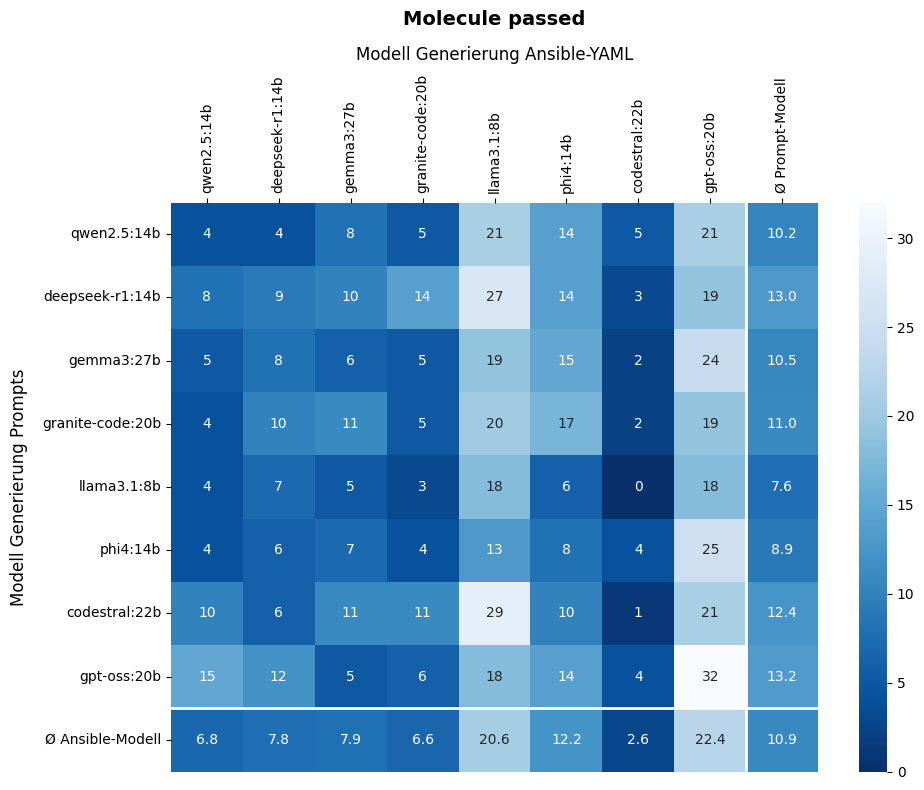

In [76]:
df_molecule_passed_extended = df_molecule_passed.copy()

# Durchschnittswerte berechnen
df_molecule_passed_extended["Ø Prompt-Modell"] = df_molecule_passed_extended.mean(axis=1)
df_molecule_passed_extended.loc["Ø Ansible-Modell"] = df_molecule_passed_extended.mean(axis=0)

# Formatierte Version für Annotationen
df_formatted = df_molecule_passed_extended.copy()

# Ganze Zahlen für alles außer Ø-Zeilen/Spalten
for r in df_formatted.index:
    for c in df_formatted.columns:
        val = df_formatted.loc[r, c]
        if r == "Ø Ansible-Modell" or c == "Ø Prompt-Modell":
            df_formatted.loc[r, c] = f"{val:.1f}"
        else:
            df_formatted.loc[r, c] = f"{int(round(val))}"

plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    df_molecule_passed_extended,
    annot=df_formatted,
    fmt="",  # fmt leer, da wir eigene Strings übergeben
    cmap="Blues_r",
    cbar=True,
)

ax.set_title("Molecule passed", fontsize=14, pad=15, weight='bold')
ax.set_xlabel("Modell Generierung Ansible-YAML", fontsize=12, labelpad=10)
ax.set_ylabel("Modell Generierung Prompts", fontsize=12, labelpad=10)

ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()

plt.xticks(rotation=90)
n = len(df_molecule_passed.columns)  
ax.axhline(n, color='white', lw=2)    
ax.axvline(n, color='white', lw=2)   

plt.tight_layout()
plt.savefig("heatmap_molecule_passed_extended.png", dpi=300, bbox_inches='tight')
plt.show()


/tmp/ipykernel_3773678/2267664722.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '35' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_formatted.loc[r, c] = f"{int(round(val))}"
/tmp/ipykernel_3773678/2267664722.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '51' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_formatted.loc[r, c] = f"{int(round(val))}"
/tmp/ipykernel_3773678/2267664722.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '43' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_formatted.loc[r, c] = f"{int(round(val))}"
/tmp/ipykernel_3773678/2267664722.py:17: FutureWarning: Setting an 

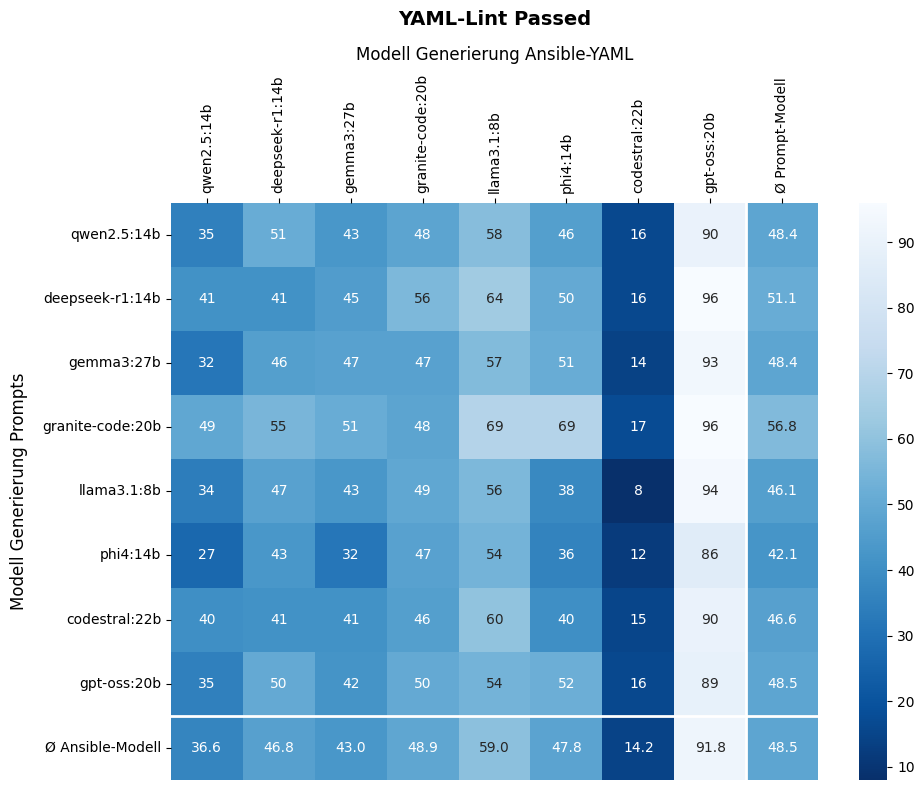

In [77]:
df_yamllint_passed_extended = df_yamllint_passed.copy()

# Durchschnittswerte berechnen
df_yamllint_passed_extended["Ø Prompt-Modell"] = df_yamllint_passed_extended.mean(axis=1)
df_yamllint_passed_extended.loc["Ø Ansible-Modell"] = df_yamllint_passed_extended.mean(axis=0)

# Formatierte Version für Annotationen
df_formatted = df_yamllint_passed_extended.copy()

# Ganze Zahlen für alles außer Ø-Zeilen/Spalten
for r in df_formatted.index:
    for c in df_formatted.columns:
        val = df_formatted.loc[r, c]
        if r == "Ø Ansible-Modell" or c == "Ø Prompt-Modell":
            df_formatted.loc[r, c] = f"{val:.1f}"
        else:
            df_formatted.loc[r, c] = f"{int(round(val))}"

plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    df_yamllint_passed_extended,
    annot=df_formatted,
    fmt="",  # fmt leer, da wir eigene Strings übergeben
    cmap="Blues_r",
    cbar=True,
)

ax.set_title("YAML-Lint Passed", fontsize=14, pad=15, weight='bold')
ax.set_xlabel("Modell Generierung Ansible-YAML", fontsize=12, labelpad=10)
ax.set_ylabel("Modell Generierung Prompts", fontsize=12, labelpad=10)

ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()

plt.xticks(rotation=90)
n = len(df_ansiblelint_passed.columns)
ax.axhline(n, color='white', lw=2)
ax.axvline(n, color='white', lw=2)

plt.tight_layout()
plt.savefig("heatmap_yamllint_passed_extended.png", dpi=300, bbox_inches='tight')
plt.show()


/tmp/ipykernel_3773678/1863285223.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '30' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_formatted.loc[r, c] = f"{int(round(val))}"
/tmp/ipykernel_3773678/1863285223.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '37' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_formatted.loc[r, c] = f"{int(round(val))}"
/tmp/ipykernel_3773678/1863285223.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '34' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_formatted.loc[r, c] = f"{int(round(val))}"
/tmp/ipykernel_3773678/1863285223.py:17: FutureWarning: Setting an 

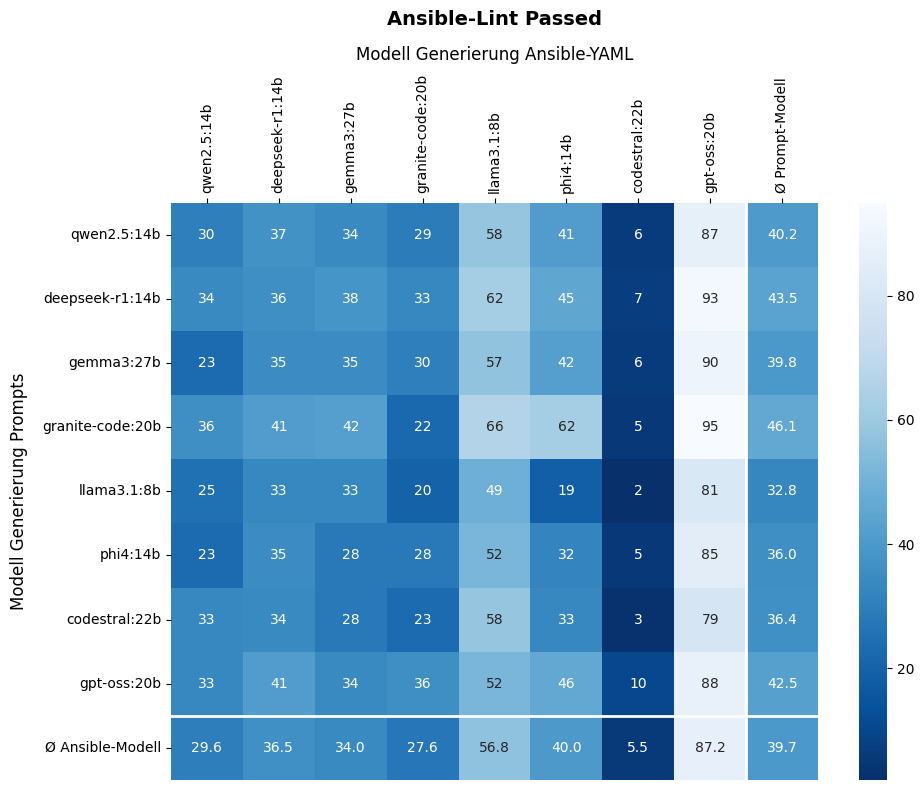

In [78]:
df_ansiblelint_passed_extended = df_ansiblelint_passed.copy()

# Durchschnittswerte berechnen
df_ansiblelint_passed_extended["Ø Prompt-Modell"] = df_ansiblelint_passed_extended.mean(axis=1)
df_ansiblelint_passed_extended.loc["Ø Ansible-Modell"] = df_ansiblelint_passed_extended.mean(axis=0)

# Formatierte Version für Annotationen
df_formatted = df_ansiblelint_passed_extended.copy()

# Ganze Zahlen für alles außer Ø-Zeilen/Spalten
for r in df_formatted.index:
    for c in df_formatted.columns:
        val = df_formatted.loc[r, c]
        if r == "Ø Ansible-Modell" or c == "Ø Prompt-Modell":
            df_formatted.loc[r, c] = f"{val:.1f}"
        else:
            df_formatted.loc[r, c] = f"{int(round(val))}"

plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    df_ansiblelint_passed_extended,
    annot=df_formatted,
    fmt="",  # fmt leer, da wir eigene Strings übergeben
    cmap="Blues_r",
    cbar=True,
)

ax.set_title("Ansible-Lint Passed", fontsize=14, pad=15, weight='bold')
ax.set_xlabel("Modell Generierung Ansible-YAML", fontsize=12, labelpad=10)
ax.set_ylabel("Modell Generierung Prompts", fontsize=12, labelpad=10)

ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()

plt.xticks(rotation=90)
n = len(df_ansiblelint_passed.columns)
ax.axhline(n, color='white', lw=2)
ax.axvline(n, color='white', lw=2)

plt.tight_layout()
plt.savefig("heatmap_ansiblelint_passed_extended.png", dpi=300, bbox_inches='tight')
plt.show()


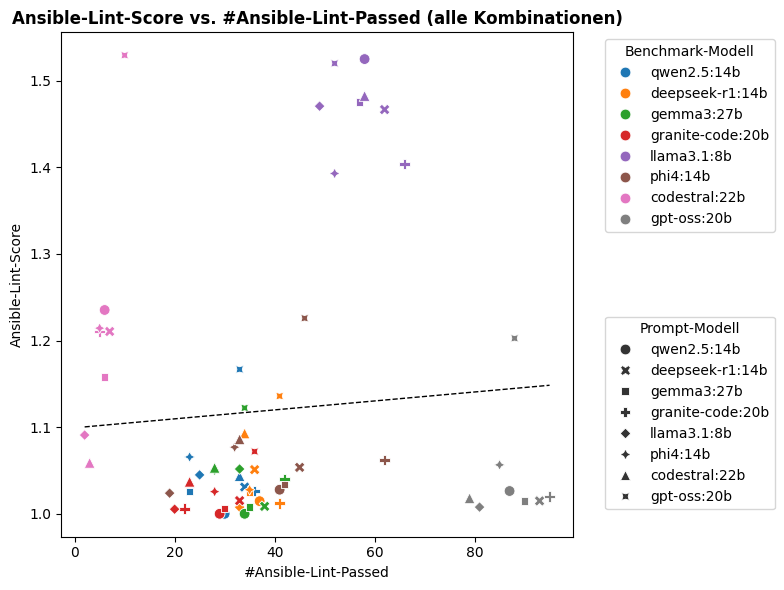

In [79]:
ansiblelint_scores_long = df_ansiblelint_scores.reset_index().melt(
    id_vars=df_ansiblelint_scores.index.name or "index",
    var_name="Benchmark-Modell",
    value_name="Ansible-Lint-Score"
)
ansible_lint_passed_long = df_ansiblelint_passed.reset_index().melt(
    id_vars=df_ansiblelint_passed.index.name or "index",
    var_name="Benchmark-Modell",
    value_name="#Ansible-Lint-Passed"
)

# Gleiche Spaltennamen für Join
ansiblelint_scores_long.rename(columns={ansiblelint_scores_long.columns[0]: "Prompt-Modell"}, inplace=True)
ansible_lint_passed_long.rename(columns={ansible_lint_passed_long.columns[0]: "Prompt-Modell"}, inplace=True)

# Kombinieren über beide Dimensionen (Prompt + Benchmark)
df_combined = pd.merge(ansiblelint_scores_long, ansible_lint_passed_long, on=["Prompt-Modell", "Benchmark-Modell"])

plt.figure(figsize=(8, 6))
scatter = sns.scatterplot(
    data=df_combined,
    x="#Ansible-Lint-Passed",
    y="Ansible-Lint-Score",
    hue="Benchmark-Modell",
    style="Prompt-Modell",
    s=60
)

sns.regplot(
    data=df_combined,
    x="#Ansible-Lint-Passed",
    y="Ansible-Lint-Score",
    scatter=False,
    color="black",
    line_kws={"linewidth": 1, "linestyle": "--"},
    ci=None
)

plt.title("Ansible-Lint-Score vs. #Ansible-Lint-Passed (alle Kombinationen)", weight='bold')
plt.xlabel("#Ansible-Lint-Passed")
plt.ylabel("Ansible-Lint-Score")

# Legenden getrennt anzeigen
hue_legend = scatter.legend_.get_texts()
handles, labels = scatter.get_legend_handles_labels()

# Anzahl der Hue-Elemente (Benchmark-Modelle)
num_hue = df_combined["Benchmark-Modell"].nunique()

# Getrennte Handles für beide Gruppen
handles_hue = handles[1:num_hue + 1]
labels_hue = labels[1:num_hue + 1]

handles_style = handles[num_hue + 2:]
labels_style = labels[num_hue + 2:]

# Zwei separate Legenden erstellen
legend1 = plt.legend(handles_hue, labels_hue, title="Benchmark-Modell", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.gca().add_artist(legend1)

plt.legend(handles_style, labels_style, title="Prompt-Modell", bbox_to_anchor=(1.05, 0.45), loc="upper left")

plt.tight_layout()
plt.savefig("scatter_plot_ansible_lint_score_vs_passed.png", dpi=300, bbox_inches='tight')

plt.show()

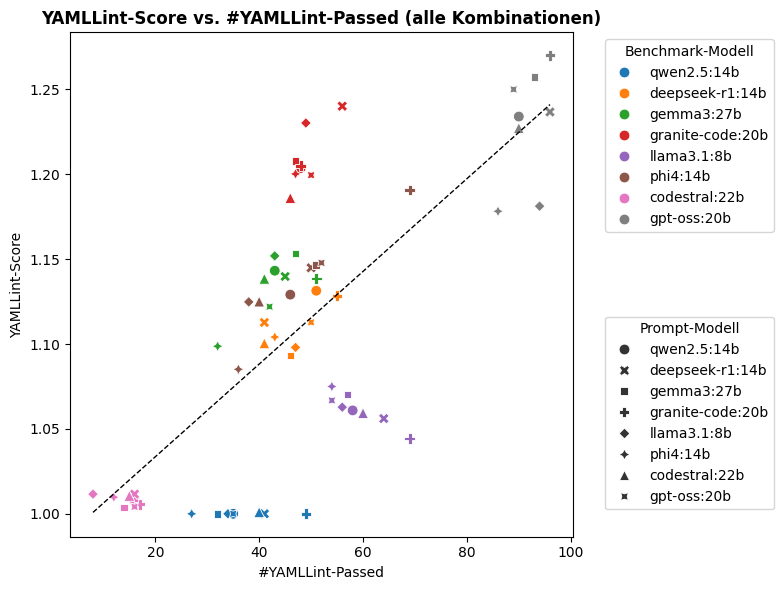

In [80]:
yamllint_scores_long = df_yamllint_scores.reset_index().melt(
    id_vars=df_yamllint_scores.index.name or "index",
    var_name="Benchmark-Modell",
    value_name="YAMLLint-Score"
)
yamllint_passed_long = df_yamllint_passed.reset_index().melt(
    id_vars=df_yamllint_passed.index.name or "index",
    var_name="Benchmark-Modell",
    value_name="#YAMLLint-Passed"
)

# Gleiche Spaltennamen für Join
yamllint_scores_long.rename(columns={yamllint_scores_long.columns[0]: "Prompt-Modell"}, inplace=True)
yamllint_passed_long.rename(columns={yamllint_passed_long.columns[0]: "Prompt-Modell"}, inplace=True)

# Kombinieren über beide Dimensionen (Prompt + Benchmark)
df_combined = pd.merge(yamllint_scores_long, yamllint_passed_long, on=["Prompt-Modell", "Benchmark-Modell"])

plt.figure(figsize=(8, 6))
scatter = sns.scatterplot(
    data=df_combined,
    x="#YAMLLint-Passed",
    y="YAMLLint-Score",
    hue="Benchmark-Modell",
    style="Prompt-Modell",
    s=60
)

sns.regplot(
    data=df_combined,
    x="#YAMLLint-Passed",
    y="YAMLLint-Score",
    scatter=False,
    color="black",
    line_kws={"linewidth": 1, "linestyle": "--"},
    ci=None
)

plt.title("YAMLLint-Score vs. #YAMLLint-Passed (alle Kombinationen)", weight='bold')
plt.xlabel("#YAMLLint-Passed")
plt.ylabel("YAMLLint-Score")

# Legenden getrennt anzeigen
hue_legend = scatter.legend_.get_texts()
handles, labels = scatter.get_legend_handles_labels()

# Anzahl der Hue-Elemente (Benchmark-Modelle)
num_hue = df_combined["Benchmark-Modell"].nunique()

# Getrennte Handles für beide Gruppen
handles_hue = handles[1:num_hue + 1]
labels_hue = labels[1:num_hue + 1]

handles_style = handles[num_hue + 2:]
labels_style = labels[num_hue + 2:]

# Zwei separate Legenden erstellen
legend1 = plt.legend(handles_hue, labels_hue, title="Benchmark-Modell", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.gca().add_artist(legend1)

plt.legend(handles_style, labels_style, title="Prompt-Modell", bbox_to_anchor=(1.05, 0.45), loc="upper left")

plt.tight_layout()
plt.savefig("scatter_plot_yamllint_score_vs_passed.png", dpi=300, bbox_inches='tight')

plt.show()

/tmp/ipykernel_3773678/1533800486.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '4 (-26)' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_formatted.loc[r, c] = f"{int(round(val))} ({sign}{int(round(diff_val))})"
/tmp/ipykernel_3773678/1533800486.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '4 (-33)' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_formatted.loc[r, c] = f"{int(round(val))} ({sign}{int(round(diff_val))})"
/tmp/ipykernel_3773678/1533800486.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '8 (-26)' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_formatted.loc[r, c] = f"{int(roun

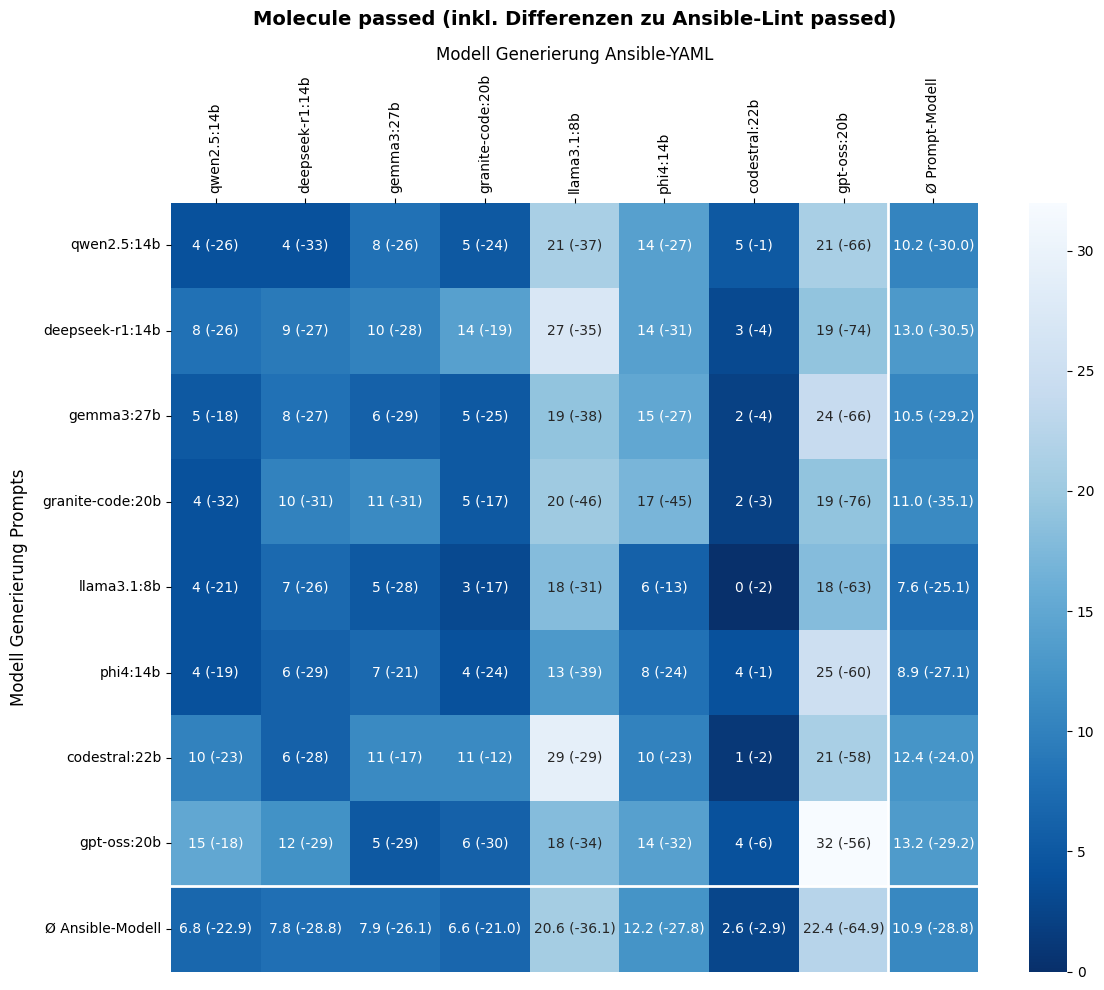

In [84]:
df_molecule_passed_extended = df_molecule_passed.copy()
df_ansiblelint_passed_extended = df_ansiblelint_passed.copy()

df_molecule_passed_extended["Ø Prompt-Modell"] = df_molecule_passed_extended.mean(axis=1)
df_molecule_passed_extended.loc["Ø Ansible-Modell"] = df_molecule_passed_extended.mean(axis=0)

df_ansiblelint_passed_extended["Ø Prompt-Modell"] = df_ansiblelint_passed_extended.mean(axis=1)
df_ansiblelint_passed_extended.loc["Ø Ansible-Modell"] = df_ansiblelint_passed_extended.mean(axis=0)

df_diff_extended = df_molecule_passed_extended - df_ansiblelint_passed_extended

df_formatted = df_molecule_passed_extended.copy()

for r in df_formatted.index:
    for c in df_formatted.columns:
        val = df_molecule_passed_extended.loc[r, c]
        diff_val = df_diff_extended.loc[r, c]
        sign = "+" if diff_val > 0 else ""

        if r == "Ø Ansible-Modell" or c == "Ø Prompt-Modell":
            df_formatted.loc[r, c] = f"{val:.1f} ({sign}{diff_val:.1f})"
        else:
            df_formatted.loc[r, c] = f"{int(round(val))} ({sign}{int(round(diff_val))})"

plt.figure(figsize=(12, 10))
ax = sns.heatmap(
    df_molecule_passed_extended,
    annot=df_formatted,
    fmt="",
    cmap="Blues_r",
    cbar=True,
)

ax.set_title("Molecule passed (inkl. Differenzen zu Ansible-Lint passed)", fontsize=14, pad=15, weight='bold')
ax.set_xlabel("Modell Generierung Ansible-YAML", fontsize=12, labelpad=10)
ax.set_ylabel("Modell Generierung Prompts", fontsize=12, labelpad=10)

ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
plt.xticks(rotation=90)

n = len(df_molecule_passed.columns)
ax.axhline(n, color='white', lw=2)
ax.axvline(n, color='white', lw=2)

plt.tight_layout()
plt.savefig("heatmap_molecule_passed_extended_diff.png", dpi=300, bbox_inches='tight')
plt.show()


/tmp/ipykernel_3773678/3607580731.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '30 (-5)' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_formatted.loc[r, c] = f"{int(round(val))} ({sign}{int(round(diff_val))})"
/tmp/ipykernel_3773678/3607580731.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '37 (-14)' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_formatted.loc[r, c] = f"{int(round(val))} ({sign}{int(round(diff_val))})"
/tmp/ipykernel_3773678/3607580731.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '34 (-9)' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_formatted.loc[r, c] = f"{int(rou

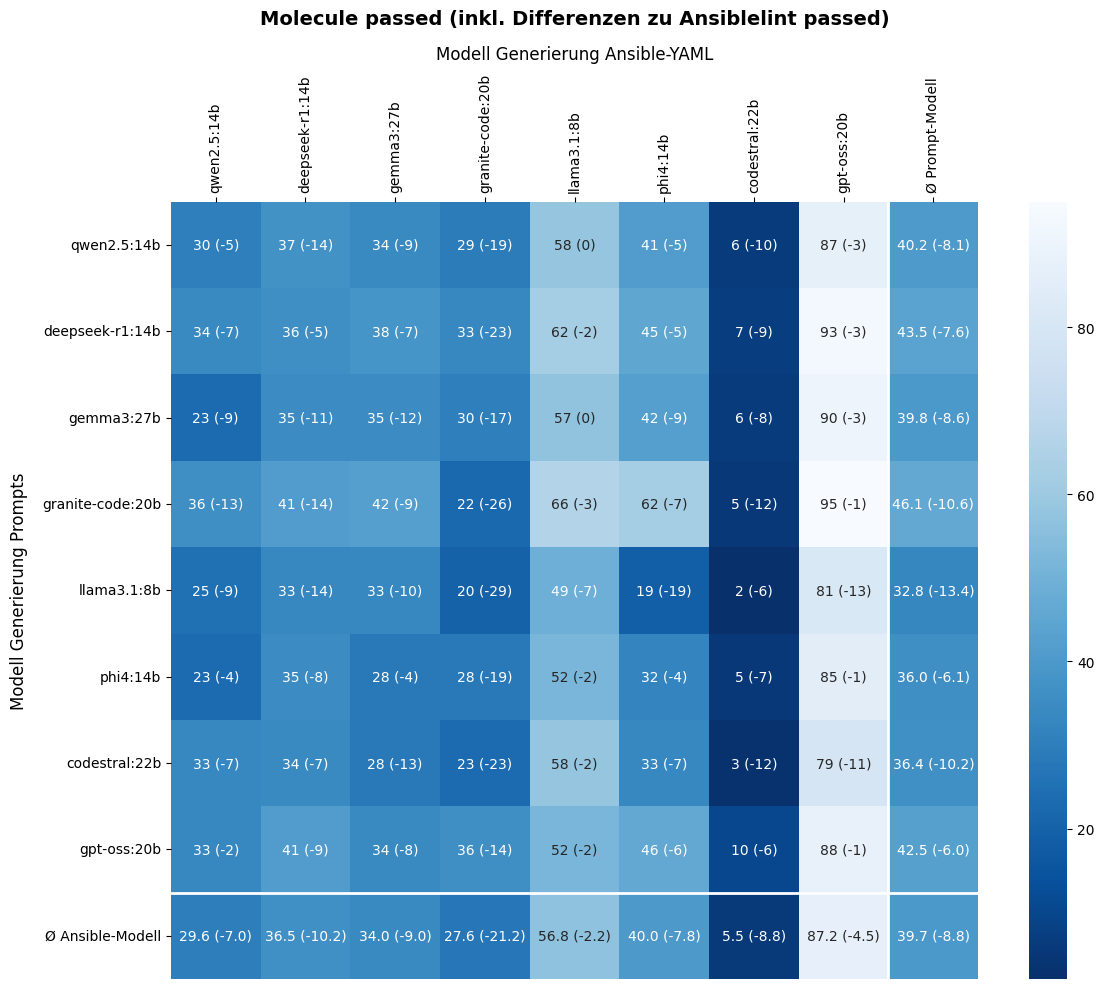

In [ ]:
df_ansiblelint_passed_extended = df_ansiblelint_passed.copy()
df_yamllint_passed_extended = df_yamllint_passed.copy()

df_ansiblelint_passed_extended["Ø Prompt-Modell"] = df_ansiblelint_passed_extended.mean(axis=1)
df_ansiblelint_passed_extended.loc["Ø Ansible-Modell"] = df_ansiblelint_passed_extended.mean(axis=0)

df_yamllint_passed_extended["Ø Prompt-Modell"] = df_yamllint_passed_extended.mean(axis=1)
df_yamllint_passed_extended.loc["Ø Ansible-Modell"] = df_yamllint_passed_extended.mean(axis=0)

df_diff_extended = df_ansiblelint_passed_extended - df_yamllint_passed_extended

df_formatted = df_ansiblelint_passed_extended.copy()

for r in df_formatted.index:
    for c in df_formatted.columns:
        val = df_ansiblelint_passed_extended.loc[r, c]
        diff_val = df_diff_extended.loc[r, c]
        sign = "+" if diff_val > 0 else ""

        if r == "Ø Ansible-Modell" or c == "Ø Prompt-Modell":
            df_formatted.loc[r, c] = f"{val:.1f} ({sign}{diff_val:.1f})"
        else:
            df_formatted.loc[r, c] = f"{int(round(val))} ({sign}{int(round(diff_val))})"

plt.figure(figsize=(12, 10))
ax = sns.heatmap(
    df_ansiblelint_passed_extended,
    annot=df_formatted,
    fmt="",
    cmap="Blues_r",
    cbar=True,
)

ax.set_title("Ansible-Lint passed (inkl. Differenzen zu YAMLLint passed)", fontsize=14, pad=15, weight='bold')
ax.set_xlabel("Modell Generierung Ansible-YAML", fontsize=12, labelpad=10)
ax.set_ylabel("Modell Generierung Prompts", fontsize=12, labelpad=10)

ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
plt.xticks(rotation=90)

n = len(df_molecule_passed.columns)
ax.axhline(n, color='white', lw=2)
ax.axvline(n, color='white', lw=2)

plt.tight_layout()
plt.savefig("heatmap_molecule_passed_extended_diff.png", dpi=300, bbox_inches='tight')
plt.show()


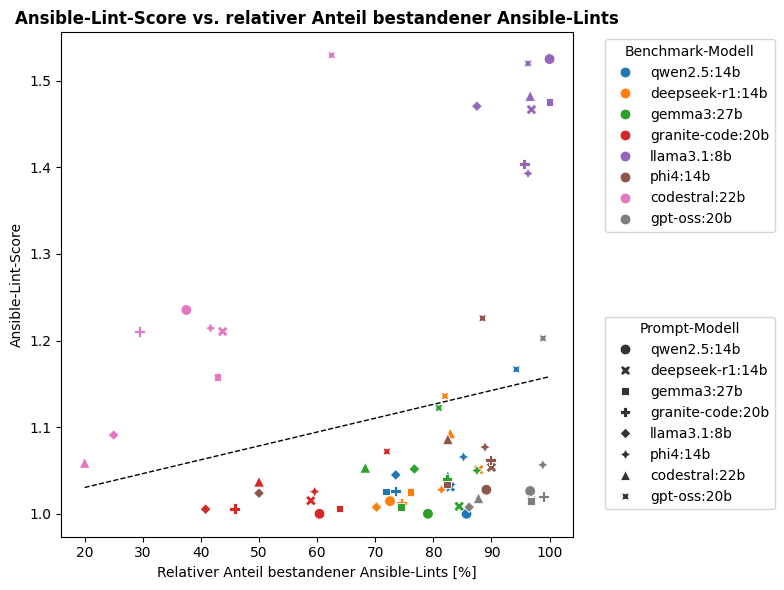

In [86]:
# --- Long-Form vorbereiten ---
ansiblelint_scores_long = df_ansiblelint_scores.reset_index().melt(
    id_vars=df_ansiblelint_scores.index.name or "index",
    var_name="Benchmark-Modell",
    value_name="Ansible-Lint-Score"
)

ansible_lint_passed_long = df_ansiblelint_passed.reset_index().melt(
    id_vars=df_ansiblelint_passed.index.name or "index",
    var_name="Benchmark-Modell",
    value_name="#Ansible-Lint-Passed"
)

yamllint_passed_long = df_yamllint_passed.reset_index().melt(
    id_vars=df_yamllint_passed.index.name or "index",
    var_name="Benchmark-Modell",
    value_name="#YAML-Lint-Passed"
)

# Einheitliche Spaltennamen für Merge
for df_ in [ansiblelint_scores_long, ansible_lint_passed_long, yamllint_passed_long]:
    df_.rename(columns={df_.columns[0]: "Prompt-Modell"}, inplace=True)

# --- Zusammenführen ---
df_combined = pd.merge(ansiblelint_scores_long, ansible_lint_passed_long, on=["Prompt-Modell", "Benchmark-Modell"])
df_combined = pd.merge(df_combined, yamllint_passed_long, on=["Prompt-Modell", "Benchmark-Modell"])

# --- Relativen Anteil berechnen ---
df_combined["Relativer Anteil (%)"] = (df_combined["#Ansible-Lint-Passed"] / df_combined["#YAML-Lint-Passed"]) * 100

# --- Scatterplot ---
plt.figure(figsize=(8, 6))
scatter = sns.scatterplot(
    data=df_combined,
    x="Relativer Anteil (%)",
    y="Ansible-Lint-Score",
    hue="Benchmark-Modell",
    style="Prompt-Modell",
    s=60
)

# Regressionslinie (optional)
sns.regplot(
    data=df_combined,
    x="Relativer Anteil (%)",
    y="Ansible-Lint-Score",
    scatter=False,
    color="black",
    line_kws={"linewidth": 1, "linestyle": "--"},
    ci=None
)

plt.title("Ansible-Lint-Score vs. relativer Anteil bestandener Ansible-Lints", weight='bold')
plt.xlabel("Relativer Anteil bestandener Ansible-Lints [%]")
plt.ylabel("Ansible-Lint-Score")

# --- Legenden separat anzeigen ---
handles, labels = scatter.get_legend_handles_labels()
num_hue = df_combined["Benchmark-Modell"].nunique()

handles_hue = handles[1:num_hue + 1]
labels_hue = labels[1:num_hue + 1]

handles_style = handles[num_hue + 2:]
labels_style = labels[num_hue + 2:]

legend1 = plt.legend(handles_hue, labels_hue, title="Benchmark-Modell", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.gca().add_artist(legend1)
plt.legend(handles_style, labels_style, title="Prompt-Modell", bbox_to_anchor=(1.05, 0.45), loc="upper left")

plt.tight_layout()
plt.savefig("scatter_plot_ansible_lint_score_vs_relative_passed.png", dpi=300, bbox_inches='tight')
plt.show()


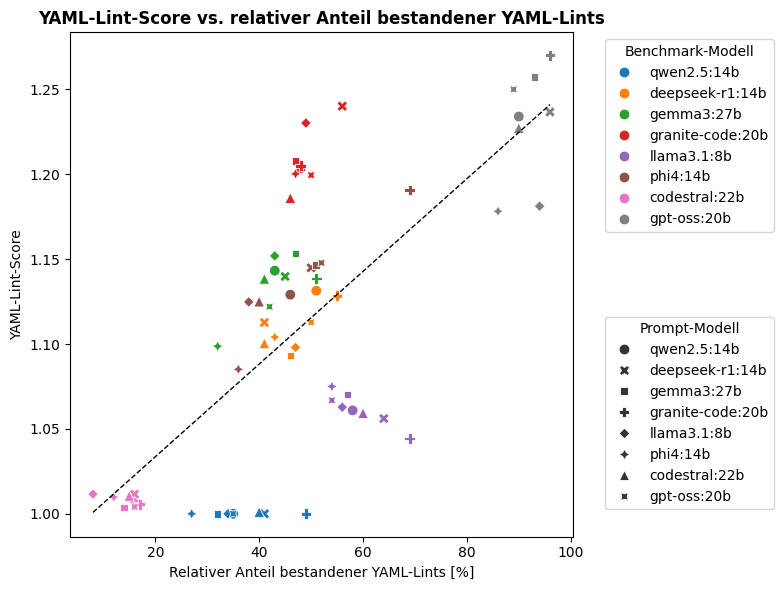

In [89]:
# --- Long-Form vorbereiten ---
yamllint_scores_long = df_yamllint_scores.reset_index().melt(
    id_vars=df_yamllint_scores.index.name or "index",
    var_name="Benchmark-Modell",
    value_name="YAML-Lint-Score"
)

yamllint_passed_long = df_yamllint_passed.reset_index().melt(
    id_vars=df_yamllint_passed.index.name or "index",
    var_name="Benchmark-Modell",
    value_name="#YAML-Lint-Passed"
)

# Einheitliche Spaltennamen
for df_ in [yamllint_scores_long, yamllint_passed_long]:
    df_.rename(columns={df_.columns[0]: "Prompt-Modell"}, inplace=True)

# --- Zusammenführen ---
df_combined_yml = pd.merge(yamllint_scores_long, yamllint_passed_long, on=["Prompt-Modell", "Benchmark-Modell"])

# --- Relative Werte berechnen ---
# Hier wird pro Prompt-Modell der Anteil der bestandenen YAML-Lints relativ zur jeweiligen maximalen Anzahl genommen
# (d.h. 100 % = beste Benchmark-Kombination des Modells)
df_combined_yml["Relativer Anteil (%)"] = df_combined_yml.groupby("Prompt-Modell")["#YAML-Lint-Passed"] \
    .transform(lambda x: (x / 100) * 100)

# --- Scatterplot ---
plt.figure(figsize=(8, 6))
scatter = sns.scatterplot(
    data=df_combined_yml,
    x="Relativer Anteil (%)",
    y="YAML-Lint-Score",
    hue="Benchmark-Modell",
    style="Prompt-Modell",
    s=60
)

# Regressionslinie (optional)
sns.regplot(
    data=df_combined_yml,
    x="Relativer Anteil (%)",
    y="YAML-Lint-Score",
    scatter=False,
    color="black",
    line_kws={"linewidth": 1, "linestyle": "--"},
    ci=None
)

plt.title("YAML-Lint-Score vs. relativer Anteil bestandener YAML-Lints", weight='bold')
plt.xlabel("Relativer Anteil bestandener YAML-Lints [%]")
plt.ylabel("YAML-Lint-Score")

# --- Legenden separat anzeigen ---
handles, labels = scatter.get_legend_handles_labels()
num_hue = df_combined_yml["Benchmark-Modell"].nunique()

handles_hue = handles[1:num_hue + 1]
labels_hue = labels[1:num_hue + 1]

handles_style = handles[num_hue + 2:]
labels_style = labels[num_hue + 2:]

legend1 = plt.legend(handles_hue, labels_hue, title="Benchmark-Modell", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.gca().add_artist(legend1)
plt.legend(handles_style, labels_style, title="Prompt-Modell", bbox_to_anchor=(1.05, 0.45), loc="upper left")

plt.tight_layout()
plt.savefig("scatter_plot_yamllint_score_vs_relative_passed.png", dpi=300, bbox_inches='tight')
plt.show()
